In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

Sets up essential libraries for data analysis, visualization, and numerical computations

Suppresses warning messages for cleaner output

In [12]:
url1 = r"C:\Users\SOURAB\Autism Project\toddler_data.csv"
url2 = r"C:\Users\SOURAB\Autism Project\Autism_Screening_Data_Combined.csv"
df2 = pd.read_csv(url1)
df1 = pd.read_csv(url2)

Loads two datasets from Google Drive links

df1 and df2 appear to be different Autism Screening datasets


# Display first five rows of Datasets

In [13]:
display(df1.head())
display(df2.head())

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jauundice,Family_ASD,Class
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


,Case_No,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Qchat-10-Score,Sex,Ethnicity,Jaundice,Family_mem_with_ASD,Who completed the test,Class/ASD Traits
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


**Purpose:** Shows the first 5 rows of the first dataset to understand its structure, revealing:

Columns A1-A10 (screening questions with binary 0/1 responses)

Demographics: Age, Sex, Jaundice, Family_ASD

Target variable: Class (YES/NO for autism diagnosis)


# Shape and Structure of the both Datasets

In [14]:
display(df1.shape)
display(df2.shape)

(6075, 15)

(1054, 19)

In [15]:
display(df1.info())
display(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6075 entries, 0 to 6074
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          6075 non-null   int64 
 1   A2          6075 non-null   int64 
 2   A3          6075 non-null   int64 
 3   A4          6075 non-null   int64 
 4   A5          6075 non-null   int64 
 5   A6          6075 non-null   int64 
 6   A7          6075 non-null   int64 
 7   A8          6075 non-null   int64 
 8   A9          6075 non-null   int64 
 9   A10         6075 non-null   int64 
 10  Age         6075 non-null   int64 
 11  Sex         6075 non-null   object
 12  Jauundice   6075 non-null   object
 13  Family_ASD  6075 non-null   object
 14  Class       6075 non-null   object
dtypes: int64(11), object(4)
memory usage: 712.0+ KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

None

**Purpose:** Provides technical details about the dataset structure:

Rows and Columns

Data types of each column

Memory usage

Non-null counts

# Delete unnecessary Columns

In [16]:
df2 = df2.drop(['Case_No','Qchat-10-Score','Ethnicity','Who completed the test'],axis=1)
   # df2=df2.drop(df2.columns[[0,12,14,17]],axis=1)
df2.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Sex,Jaundice,Family_mem_with_ASD,Class/ASD Traits
0,0,0,0,0,0,0,1,1,0,1,28,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,f,no,yes,Yes


It deletes all the unnecessary Columns that are not used to train our ML Model.

In [17]:
df2.shape

(1054, 15)

In [18]:
df2.columns = df2.columns.str.strip().str.replace('/', '_')
df2.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Sex,Jaundice,Family_mem_with_ASD,Class_ASD Traits
0,0,0,0,0,0,0,1,1,0,1,28,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,36,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,36,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,24,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,20,f,no,yes,Yes


strip() function remove all the white spaces from the front and back of the column name.

# Changing the data of Age_Mons column(from Months to Years) in df2

In [19]:
df2['Age_Mons'] = (df2['Age_Mons'] / 12).round().astype(int)
df2.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age_Mons,Sex,Jaundice,Family_mem_with_ASD,Class_ASD Traits
0,0,0,0,0,0,0,1,1,0,1,2,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,3,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,3,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,2,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,2,f,no,yes,Yes


The data inside Age_Mons column is in months, so the data is converted into years and the roundoff the years by round() function.
astype(int) function converts the data into integer type.

# Rename Columns

In [20]:
df2.rename(columns={'Age_Mons': 'Age','Family_mem_with_ASD':'Family_ASD','Class_ASD Traits':'Is_ASD'}, inplace=True)
df1.rename(columns={'Jauundice': 'Jaundice','Class':'Is_ASD'}, inplace=True)
display(df1.head())
display(df2.head())

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD
0,1,1,0,1,0,0,1,1,0,0,15,m,no,no,NO
1,0,1,1,1,0,1,1,0,1,0,15,m,no,no,NO
2,1,1,1,0,1,1,1,1,1,1,15,f,no,yes,YES
3,1,1,1,1,1,1,1,1,0,0,16,f,no,no,YES
4,1,1,1,1,1,1,1,1,1,1,15,f,no,no,YES


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD
0,0,0,0,0,0,0,1,1,0,1,2,f,yes,no,No
1,1,1,0,0,0,1,1,0,0,0,3,m,yes,no,Yes
2,1,0,0,0,0,0,1,1,0,1,3,m,yes,no,Yes
3,1,1,1,1,1,1,1,1,1,1,2,m,no,no,Yes
4,1,1,0,1,1,1,1,1,1,1,2,f,no,yes,Yes


To merge both datasets, we need to make their column names same.
By rename() function column names of both datasets is changed.

# Merge both Datasets

In [21]:
df = pd.concat([df1, df2], ignore_index=True)

In [22]:
cols_to_fix = ['Is_ASD', 'Jaundice', 'Family_ASD']
for col in cols_to_fix:
    df[col] = df[col].str.strip().str.capitalize()

The column data of columns(Is_ASD, Jaundice, Family_ASD) is modified by strip() function (remove white spaces) and capitalize() function (capitalize first letter and keep all remaining letters in lower case).

In [23]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7124,0,0,0,0,0,0,0,0,0,1,2,f,No,Yes,No
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes
7126,1,0,1,1,1,1,1,1,1,1,2,m,Yes,No,Yes
7127,1,0,0,0,0,0,0,1,0,1,2,m,No,Yes,No


#Check Shape and Structure

In [24]:
df.shape

(7129, 15)

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7129 entries, 0 to 7128
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   A1          7129 non-null   int64 
 1   A2          7129 non-null   int64 
 2   A3          7129 non-null   int64 
 3   A4          7129 non-null   int64 
 4   A5          7129 non-null   int64 
 5   A6          7129 non-null   int64 
 6   A7          7129 non-null   int64 
 7   A8          7129 non-null   int64 
 8   A9          7129 non-null   int64 
 9   A10         7129 non-null   int64 
 10  Age         7129 non-null   int64 
 11  Sex         7129 non-null   object
 12  Jaundice    7129 non-null   object
 13  Family_ASD  7129 non-null   object
 14  Is_ASD      7129 non-null   object
dtypes: int64(11), object(4)
memory usage: 835.6+ KB


# Checking Null values

In [26]:
df.isna().sum().sum()

np.int64(0)

Check if there exist any Null Value. The output shows that there is no Null value in the df dataset

In [27]:
df.dtypes

A1             int64
A2             int64
A3             int64
A4             int64
A5             int64
A6             int64
A7             int64
A8             int64
A9             int64
A10            int64
Age            int64
Sex           object
Jaundice      object
Family_ASD    object
Is_ASD        object
dtype: object

Check datatypes of each column

In [28]:
unique_list=['Sex','Is_ASD','Jaundice','Family_ASD']
for col in unique_list:
    print(f"{col}: {df[col].unique()}")

Sex: ['m' 'f']
Is_ASD: ['No' 'Yes']
Jaundice: ['No' 'Yes']
Family_ASD: ['No' 'Yes']


The code examines the distinct/unique values present in four key categorical columns of the dataset to understand the data structure and possible values.

# Check Duplicate values

In [29]:
df.duplicated().sum()

np.int64(1320)

Check for duplicate values. Output shows that there is 1320 duplicate values present in the dataset

# Remove Duplicate values

In [30]:
df.drop_duplicates(inplace=True)
print("Number of duplicates after removal:", df.duplicated().sum())

Number of duplicates after removal: 0


drop_duplicates() function remove all the duplicate values, and if we check duplicate values again, it shows '0' means there is no duplicate values.

# Finding Outliers

In [31]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes


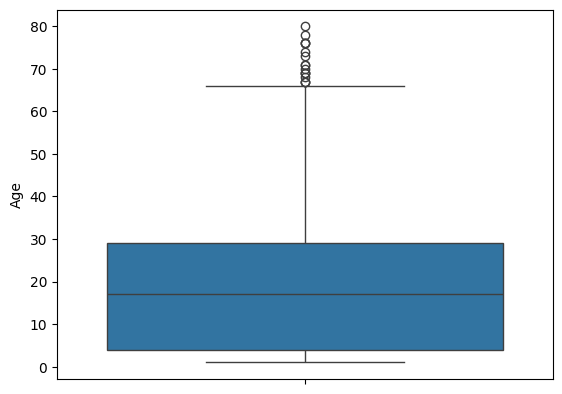

In [32]:
sns.boxplot(df['Age']);

The boxplot displays the age distribution in the dataset.

Most ages fall between about 4 and 30, with a median around 18.

There are many outliers above 65, indicating a few much older individuals.

The distribution is right-skewed, with a longer tail towards higher ages.

In [33]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes


# Removing Outliers

In [34]:
mean = df['Age'].mean()
std = df['Age'].std()

df['z_score'] = (df['Age'] - mean) / std
#outliers = df[(df['z_score'] > 3) | (df['z_score'] < -3)]
df = df[(df['z_score'] <= 3) & (df['z_score'] >= -3)]


In [35]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD,z_score
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No,-0.257278
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No,-0.257278
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes,-0.257278
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes,-0.192103
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes,-0.257278
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes,-1.104554
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes,-1.104554
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes,-1.104554
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes,-1.169729


<Axes: ylabel='Age'>

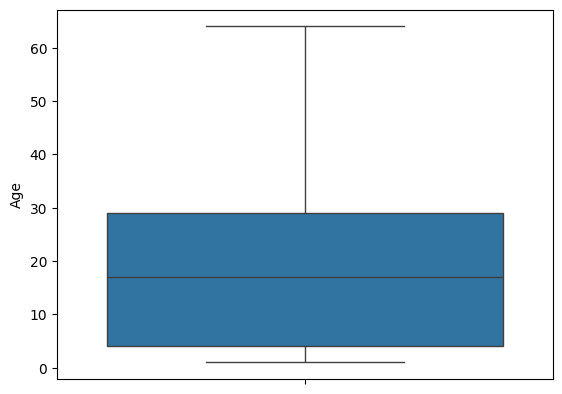

In [36]:
sns.boxplot(df['Age'])

This updated boxplot of "Age" shows the distribution after removing outliers.

The plot displays ages mostly between about 2 and 65, with no individual points beyond the whiskers, indicating that extreme ages have been excluded.

The box (interquartile range) and median remain similar, but the visualization now focuses only on the central data, providing a clearer view of the main age distribution without the influence of very old age outliers.

# Finding Average Age

In [37]:
average_age = df['Age'].mean()
print(average_age)

18.744037331489803


This code snippet calculates and displays the mean (average) age of all individuals in your Autism Screening dataset.

#Distribution of Age

In [38]:
df['Age'].value_counts()

Age
3     672
2     508
4     261
20    186
1     176
     ... 
61      7
62      6
59      5
64      4
63      4
Name: count, Length: 64, dtype: int64

Analyzes the frequency distribution of ages in the dataset, showing that ages 3 (672 cases), 2 (508 cases), and 4 (261 cases) are most common, with age range spanning from 1 to 80 years.

# Visualize the distribution of ages in the dataset using a histogram.

<Axes: xlabel='Age', ylabel='Count'>

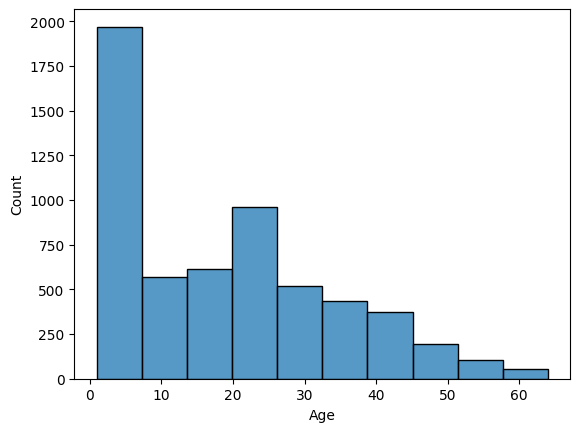

In [39]:
sns.histplot(df['Age'], bins = 10)

The histogram shows most individuals in the dataset are young, with the highest count in the 0–10 age range.

As age increases, the number of individuals decreases steadily.

The age distribution is right-skewed, with relatively few older individuals.

# Create a violin plot to explore the distribution and density of ages.


<Axes: ylabel='Age'>

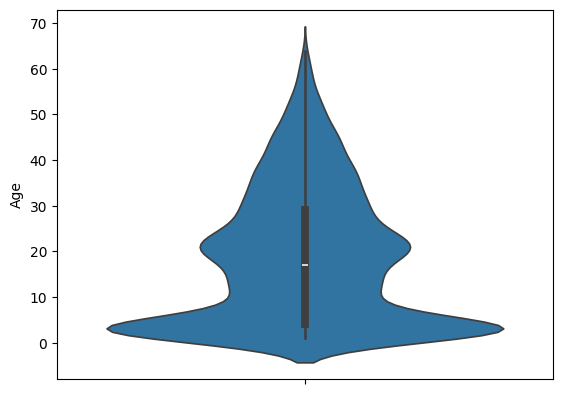

In [40]:
sns.violinplot(df['Age'])

The violin plot shows that most ages are concentrated at the lower end (younger ages).

The plot is wider at the bottom, indicating a higher density of young individuals.

The distribution tapers off as age increases, showing fewer older individuals in the dataset.

Overall, the age distribution is right-skewed with a peak at lower ages.



# Plot the kernel density estimate (KDE) of the Age variable

<Axes: xlabel='Age', ylabel='Density'>

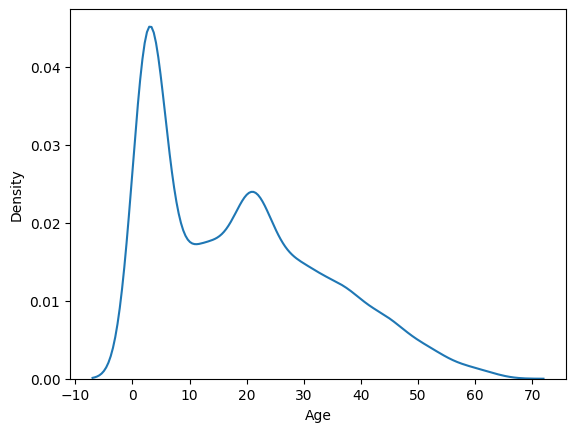

In [41]:
sns.kdeplot(df['Age'])

The KDE plot shows the highest density of ages is at the younger end, peaking around early childhood.

There is a secondary smaller peak in the early twenties.

The curve drops steadily for older ages, confirming most individuals in the dataset are young, with fewer adults and seniors.

# Distribution (count and percentage) of the Sex column

In [42]:
df['Sex'].value_counts()

Sex
m    3395
f    2391
Name: count, dtype: int64

Shows raw counts of gender distribution: 3,395 males and 2,391 females in the dataset

# Plot a bar chart comparing the number of males and females in the dataset


<Axes: ylabel='Sex'>

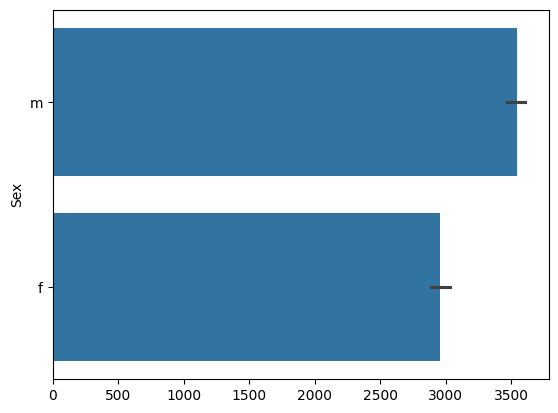

In [43]:
sns.barplot(df['Sex'])

The bar chart shows there are more males ("m") than females ("f") in the dataset.

Both groups are well represented, but the male count is higher than the female count.

In [44]:
df['Sex'].value_counts(normalize=True)*100

Sex
m    58.676115
f    41.323885
Name: proportion, dtype: float64

Converts gender counts to percentages, revealing 58.6% males and 41.3% females, showing higher male representation consistent with ASD prevalence patterns.

# Distribution (count and percentage) of individuals with Jaundice

In [45]:
df['Jaundice'].value_counts()

Jaundice
No     4646
Yes    1140
Name: count, dtype: int64

Shows Jaundice history distribution, revealing 4646 people does not have Jaundice and 1140 people have Jaundice.

# Create a count plot to examine the frequency of Jaundice responses.


<Axes: xlabel='Jaundice', ylabel='count'>

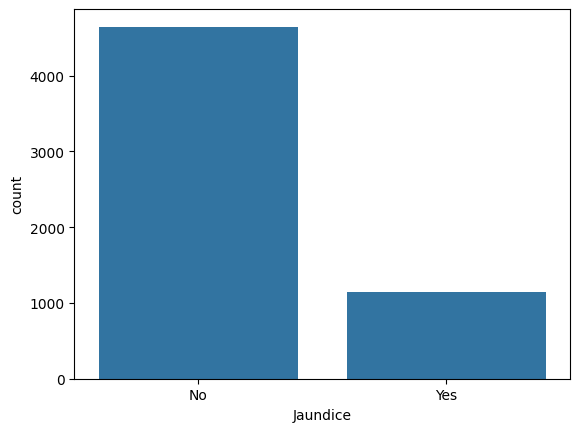

In [46]:
sns.countplot(x= df['Jaundice'])

The count plot shows most individuals responded "No" to having jaundice, while a much smaller group responded "Yes".

This indicates jaundice is less common in the dataset.



In [47]:
df['Jaundice'].value_counts(normalize=True)*100

Jaundice
No     80.297269
Yes    19.702731
Name: proportion, dtype: float64

Examines Jaundice history distribution as percentages: 80.2% had no jaundice history, 19.7% had jaundice history.

#How many people have a family history of ASD?

In [48]:
df['Family_ASD'].value_counts()

Family_ASD
No     4650
Yes    1136
Name: count, dtype: int64

Shows raw counts of family autism history: 4,650 cases with no family history, 1,136 cases with family ASD history.

# Visualize the distribution of Family_ASD values using a bar chart

<Axes: ylabel='Family_ASD'>

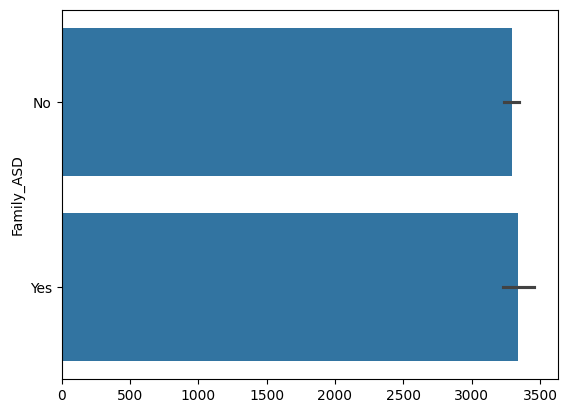

In [49]:
sns.barplot(df['Family_ASD'])

The bar chart shows the dataset has a nearly equal number of individuals with ("Yes") and without ("No") a family history of ASD.

Both groups are well represented, allowing for balanced comparisons in analysis.

#Distribution of ASD

In [50]:
df['Is_ASD'].value_counts()

Is_ASD
No     3681
Yes    2105
Name: count, dtype: int64

Reveals the target variable distribution showing 3,681 "No ASD" cases and 2,105 "ASD positive" cases (approximately 63.6% vs 36.4%).

# Create a pie chart showing the percentage split between ASD and non-ASD


([<matplotlib.patches.Wedge at 0x1b7416835c0>,
 [Text(-0.45641325706288627, 1.0008431139680425, 'No'),
  Text(0.45641358317894254, -1.0008429652496733, 'Yes')],
 [Text(-0.2489526856706652, 0.5459144258007503, '63.6%'),
  Text(0.24895286355215046, -0.5459143446816399, '36.4%')])

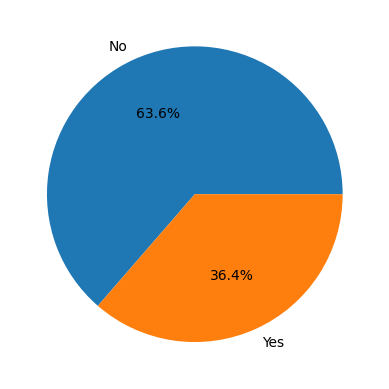

In [51]:
plt.pie(df['Is_ASD'].value_counts(), labels = df['Is_ASD'].value_counts().index, autopct='%1.1f%%')

The pie chart shows that 36.4% of individuals have ASD (“Yes”) and 63.6% do not have ASD (“No”).

Non-ASD cases make up the majority of the dataset.

# Finding Mean, Median, Min, and Max scores of each A1–A10 screening question.

In [52]:
a_columns = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
df[a_columns].agg(['mean', 'median', 'min', 'max']).T

,mean,median,min,max
A1,0.692361,1.0,0.0,1.0
A2,0.488075,0.0,0.0,1.0
A3,0.533529,1.0,0.0,1.0
A4,0.559281,1.0,0.0,1.0
A5,0.551676,1.0,0.0,1.0
A6,0.459730,0.0,0.0,1.0
A7,0.524715,1.0,0.0,1.0
A8,0.531974,1.0,0.0,1.0
A9,0.441929,0.0,0.0,1.0
A10,0.596958,1.0,0.0,1.0


# Use a bar plot to display average A1–A10 scores for each class label.

<Axes: ylabel='None'>

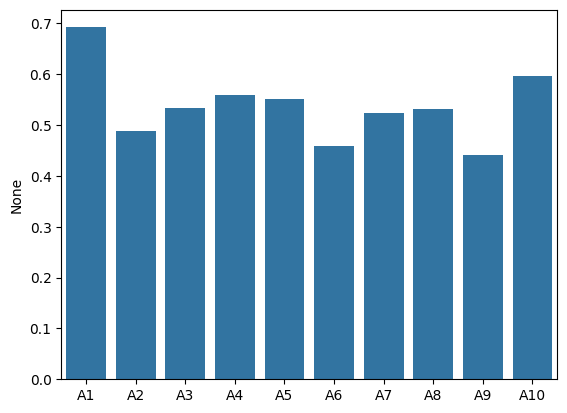

In [53]:
questions = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
average_score = df[questions].mean()
sns.barplot(x= questions, y = average_score)

The bar plot displays the average scores for each question (A1–A10).

A1 has the highest average score, while A9 and A6 have the lowest.

There is variability in average responses, suggesting some questions are more likely to receive higher scores than others.



# Plot the average scores of A1–A10 questions using a line chart.

<Axes: xlabel='None'>

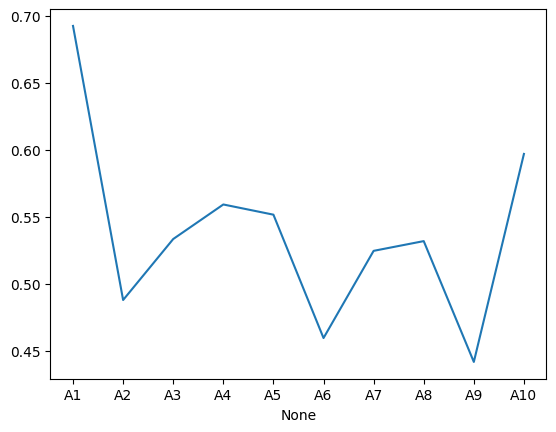

In [54]:
questions = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
average_score = df[questions].mean()

sns.lineplot(x= average_score.index, y = average_score.values)

The line chart shows the average scores for questions A1–A10.

A1 has the highest average score, while A9 is the lowest.

The scores fluctuate across the questions, indicating varying difficulty or response patterns for each item.

# Which screening question has the highest average score?

In [55]:
mean_scores = df[a_columns].mean()
highest_avg_question = mean_scores.idxmax()
highest_avg_value = mean_scores.max()
print(f"The screening question with the highest average score is {highest_avg_question} with a mean of {highest_avg_value:.2f}")

The screening question with the highest average score is A1 with a mean of 0.69


It states that "The screening question with the highest average score is A1 with a mean of 0.69". This means that among all the screening questions, A1 was the most frequently answered with a '1' (indicating a positive response to that question).

Provides comprehensive descriptive statistics for all 10 screening questions, showing mean response rates ranging from 44% (A9) to 69% (A1), with median values mostly being 0 or 1(This reinforces that the screening questions have binary responses (0 or 1)).This highlights that not all screening questions have the same frequency of positive responses, suggesting that some questions might be more commonly answered in a certain way than others.

# Is there any correlation among A1 to A10 responses?

In [56]:
df[a_columns].corr()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10
A1,1.000000,0.102468,0.051557,0.118062,0.097125,0.094167,0.095980,0.122267,0.092474,0.111913
A2,0.102468,1.000000,0.118041,0.113233,0.085561,0.148274,0.033376,0.065626,0.093290,0.054411
A3,0.051557,0.118041,1.000000,0.360416,0.211753,0.212583,0.055641,0.072761,0.234929,0.101840
A4,0.118062,0.113233,0.360416,1.000000,0.206338,0.237011,0.108064,0.092463,0.267016,0.108758
A5,0.097125,0.085561,0.211753,0.206338,1.000000,0.349730,0.191448,0.116965,0.323553,0.232747
A6,0.094167,0.148274,0.212583,0.237011,0.349730,1.000000,0.196702,0.145915,0.413025,0.212164
A7,0.095980,0.033376,0.055641,0.108064,0.191448,0.196702,1.000000,0.074858,0.174434,0.199417
A8,0.122267,0.065626,0.072761,0.092463,0.116965,0.145915,0.074858,1.000000,0.124667,0.137390
A9,0.092474,0.093290,0.234929,0.267016,0.323553,0.413025,0.174434,0.124667,1.000000,0.174948
A10,0.111913,0.054411,0.101840,0.108758,0.232747,0.212164,0.199417,0.137390,0.174948,1.000000


The correlation matrix shows how responses to each screening question are related to responses to every other screening question. A higher positive value indicates a stronger tendency for individuals to answer '1' to both questions, while a value closer to zero suggests little linear relationship.

This specifically points out the highest correlation coefficients:

A6 and A9 have a correlation of 0.41.

A3 and A4 have a correlation of 0.36.

A5 and A6 have a correlation of 0.35.

These higher correlations suggest that individuals who answer '1' to one of these pairs of questions are more likely to answer '1' to the other question in the pair as well. This could indicate that these pairs of questions are tapping into similar aspects of the traits being screened for.

# Create a heatmap showing correlation between screening questions A1 through A10.

<Axes: >

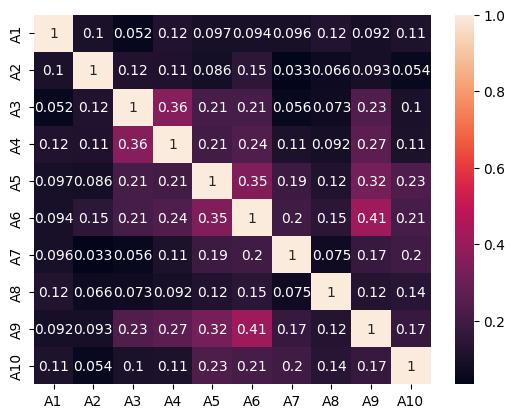

In [57]:
questions = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10']
corr = df[questions].corr()
sns.heatmap(data = corr, annot = True)

The heatmap displays pairwise correlations between questions A1–A10.

Most correlations are weak to moderate; the highest are around 0.41 (e.g., A6 and A9).

Some question pairs (e.g., A4 & A3, A9 & A6) are more strongly correlated, suggesting they may capture related aspects.

Overall, the questions have low redundancy and measure somewhat distinct concepts.



#Does the average age differ between ASD(Yes/No)


In [58]:
df.groupby('Is_ASD')['Age'].mean()

Is_ASD
No     19.869872
Yes    16.775297
Name: Age, dtype: float64

Compares average ages between ASD groups, showing Non-ASD group averages 19.87 years while ASD group averages 16.77 years, indicating younger individuals are more likely to have ASD diagnosis.

It's important to note that this is an observation from the data and doesn't necessarily imply a causal relationship.

# Use a bar plot to compare mean Age across ASD groups.


<Axes: xlabel='Is_ASD', ylabel='Age'>

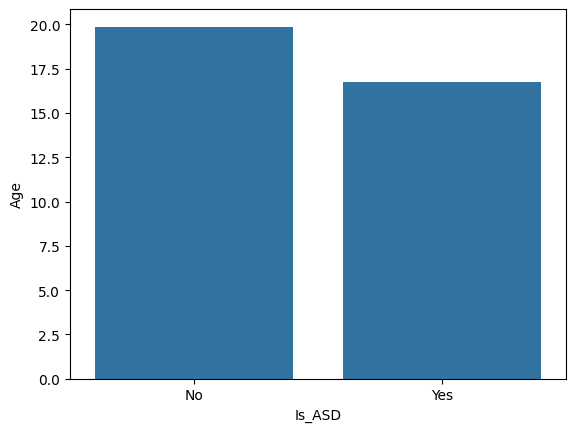

In [59]:
sns.barplot(x = df['Is_ASD'].value_counts().index, y = df.groupby('Is_ASD')['Age'].mean())

The bar plot shows the mean age is higher in the non-ASD group ("No") than in the ASD group ("Yes").

This suggests that, on average, individuals with ASD are younger than those without ASD in the dataset.



# Plot a violin graph to show age variation by ASD diagnosis

<Axes: xlabel='Is_ASD', ylabel='Age'>

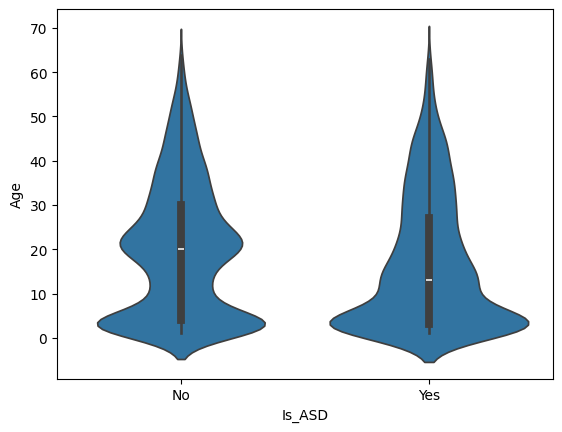

In [60]:
sns.violinplot(x=df['Is_ASD'], y= df['Age'])

The violin plot shows age distributions for ASD ("Yes") and non-ASD ("No") groups.

Both groups are skewed toward younger ages, but the ASD group ("Yes") has a slightly lower median age and a higher concentration of younger individuals.

The shapes confirm younger ages are more common in the ASD group compared to the non-ASD group.

#Compare the mean scores of A1–A10 between Family_ASD(Yes/No).

In [61]:
df.groupby('Family_ASD')[a_columns].mean()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10
Family_ASD,,,,,,,,,,
No,0.674624,0.483871,0.518495,0.542366,0.537849,0.442366,0.517849,0.520860,0.423226,0.578925
Yes,0.764965,0.505282,0.595070,0.628521,0.608275,0.530810,0.552817,0.577465,0.518486,0.670775


The key insight is that having a family history of ASD appears to be associated with higher average scores on the screening questions. The code output shows the mean score for each question for both the 'No' (no family history) and 'Yes' (family history) groups. By comparing the mean scores for each question across the two groups, you can see that the 'Yes' group consistently has higher average scores for all A1-A10 questions.

This finding supports the idea that family history is a relevant factor in understanding potential ASD indicators.

# Checking for any Gender imbalance in ASD diagnosis.

In [62]:
df.groupby('Sex')['Is_ASD'].value_counts().unstack()

Is_ASD,No,Yes
Sex,,
f,1534,857
m,2147,1248


For females ('f'), 857 have an ASD diagnosis ('Yes'), and 2147 do not ('No'). For males ('m'), 1248 have an ASD diagnosis ('Yes'), and 2147 do not ('No'). The proportion of individuals diagnosed with ASD is very similar for both males and females

# Generate a count plot of ASD outcomes grouped by gender.

<Axes: xlabel='Is_ASD', ylabel='count'>

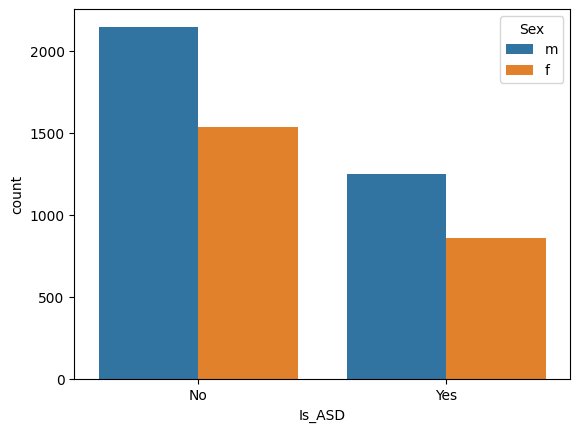

In [63]:
sns.countplot(x= df['Is_ASD'], hue = df['Sex'])

The count plot compares ASD outcomes for males (m) and females (f).

In both ASD (“Yes”) and non-ASD (“No”) groups, males outnumber females.

The difference is larger in the non-ASD group, but is present for both categories.

ASD is more common among males than females in this dataset.

#Are people with jaundice more likely to be diagnosed with ASD.

In [64]:
df.groupby('Jaundice')['Is_ASD'].value_counts().unstack()

Is_ASD,No,Yes
Jaundice,,
No,3031,1615
Yes,650,490


The code output shows the individuals with and without ASD within the 'Yes' and 'No' jaundice history groups. For the 'Yes' jaundice group, 490 have an ASD diagnosis, while for the 'No' jaundice group, approximately 1615 have an ASD diagnosis.

# Generate a count plot to show ASD diagnosis split by jaundice history

<Axes: xlabel='Is_ASD', ylabel='count'>

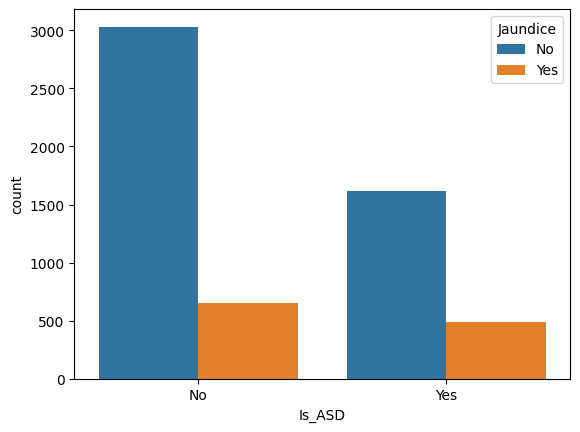

In [65]:
sns.countplot(x = df['Is_ASD'], hue= df['Jaundice'])

The count plot shows most individuals (both ASD and non-ASD) do not have a history of jaundice.

However, the proportion of individuals with a history of jaundice (“Yes”) is higher in the ASD group than in the non-ASD group.

This suggests a possible association between a history of jaundice and ASD diagnosis in the dataset.



#Is ASD diagnosis more prevalent in individuals with family history of ASD?

In [66]:
df.groupby('Family_ASD')['Is_ASD'].value_counts(normalize=True).unstack() * 100

Is_ASD,No,Yes
Family_ASD,,
No,65.720430,34.279570
Yes,55.017606,44.982394


The output confirms that individuals with a family history of ASD are more likely to be diagnosed with ASD (44.98%) compared to those without a family history (34.28%). This highlights family history as a significant factor in ASD diagnosis within this dataset.

# Create a count plot comparing ASD occurrence for individuals with/without family ASD history.

<Axes: xlabel='Family_ASD', ylabel='count'>

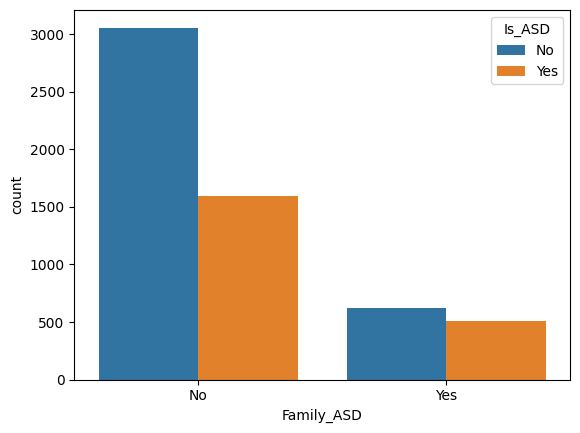

In [67]:
sns.countplot(x='Family_ASD', hue='Is_ASD', data=df)

The count plot shows ASD occurrence is higher among individuals with a family history of ASD ("Yes") compared to those without ("No").

In the "No Family_ASD" group, most individuals do not have ASD.

In the "Yes Family_ASD" group, the counts of ASD (“Yes”) and non-ASD (“No”) are much closer, indicating a stronger association between family ASD history and ASD occurrence.

#Use NumPy to calculate the Standard Deviation of age.

In [68]:
np.std(df['Age'])

np.float64(15.025867310592192)

The standard deviation of age, which is approximately 15.34, tells us about the spread or variability of ages in the dataset. A larger standard deviation indicates that the ages are more spread out from the average age, while a smaller standard deviation would mean the ages are clustered more closely around the average. In this case, a standard deviation of 15.0259 suggests there's a fair amount of variation in the ages of individuals in the dataset.

In [69]:
df['Total_score']=df[a_columns].sum(axis=1)

In [70]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD,z_score,Total_score
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No,-0.257278,5
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No,-0.257278,6
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes,-0.257278,9
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes,-0.192103,8
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes,-0.257278,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes,-1.104554,4
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes,-1.104554,7
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes,-1.104554,5
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes,-1.169729,5


# Use a bar plot to compare average total scores based on family ASD history.


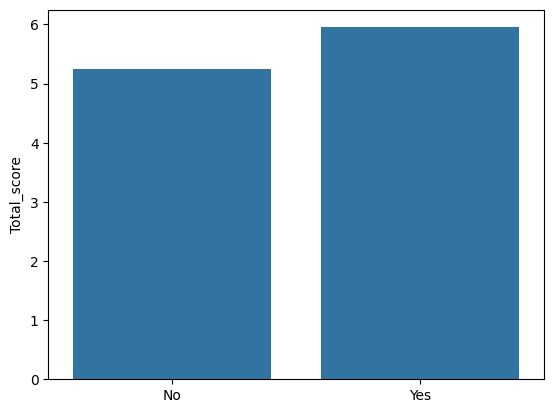

In [71]:
sns.barplot(x= df['Family_ASD'].unique(), y= df.groupby('Family_ASD')['Total_score'].mean())
plt.show()

The bar plot shows that individuals with a family history of ASD ("Yes") have a higher average total score compared to those without ("No").

This suggests a possible link between family ASD history and increased total scores on the assessment.



# Plot a histogram to explore how total screening scores are distributed.


<Axes: xlabel='Total_score', ylabel='Count'>

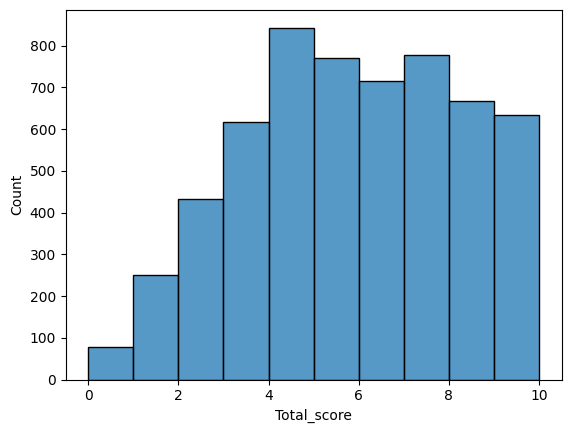

In [72]:
sns.histplot(df['Total_score'], bins=10)

The histogram shows that total screening scores are spread across the full range (0–10).

Most scores cluster between 4 and 8, with fewer individuals at the very low or very high ends.

The distribution suggests a slight concentration in the mid-to-upper score range.



#Find the Mode and Median of the Total Screening score (A1–A10 sum).

In [73]:
np.mean(df['Total_score'])

np.float64(5.380228136882129)

In [74]:
np.median(df['Total_score'])

np.float64(5.0)

# Normalize (min-max scale) the age values

In [75]:
df['Age_Norm'] = (df['Age'] - df['Age'].min()) / (df['Age'].max() - df['Age'].min())

In [76]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD,z_score,Total_score,Age_Norm
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No,-0.257278,5,0.222222
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No,-0.257278,6,0.222222
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes,-0.257278,9,0.222222
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes,-0.192103,8,0.238095
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes,-0.257278,10,0.222222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes,-1.104554,4,0.015873
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes,-1.104554,7,0.015873
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes,-1.104554,5,0.015873
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes,-1.169729,5,0.000000


This column contains the normalized values of the 'Age' column. Normalization (specifically min-max scaling in this case) rescales the age values so that they fall within a range of 0 to 1. This is often done in data preprocessing for machine learning models or when comparing features with different scales.

#Calculate the Skewness and Kurtosis of age.

In [77]:
from scipy.stats import skew, kurtosis

age_skewness = skew(df['Age'])
age_kurtosis = kurtosis(df['Age'])

print(f"Skewness of Age: {age_skewness:.2f}")
print(f"Kurtosis of Age: {age_kurtosis:.2f}")

Skewness of Age: 0.65
Kurtosis of Age: -0.50


**Skewness (0.65):** A positive skewness value indicates that the distribution of age is skewed to the right. This means there is a longer tail on the right side of the distribution, suggesting there are more individuals in the older age range, although the majority are younger.

**Kurtosis (-0.50):** The kurtosis value of -0.50 suggests that the age distribution is slightly platykurtic. This means the distribution has lighter tails and is flatter around the mean compared to a normal distribution. In simpler terms, there are fewer extreme age values than you would expect in a normal distribution.

#Distribution of Total_score

In [78]:
df['Total_score'].value_counts()

Total_score
4     843
7     778
5     770
6     716
8     667
3     616
9     473
2     432
1     251
10    161
0      79
Name: count, dtype: int64

This output shows the distribution of the total screening scores (the sum of responses to questions A1-A10). It tells us how many individuals received each possible total score. For example, a score of 4 is the most frequent, occurring 843 times, while a score of 0 is the least frequent, occurring 81 times. This gives us a sense of the most common and uncommon screening outcomes in the dataset.

#What is the average Total_score of Family ASD vs non-ASD individuals?


In [79]:
df.groupby('Family_ASD')["Total_score"].mean()

Family_ASD
No     5.240430
Yes    5.952465
Name: Total_score, dtype: float64

Individuals with no family history of ASD have an average total score of approximately 5.24. Individuals with a family history of ASD have a higher average total score of approximately 5.95.

# Use a bar plot to compare average total scores based on family ASD history.


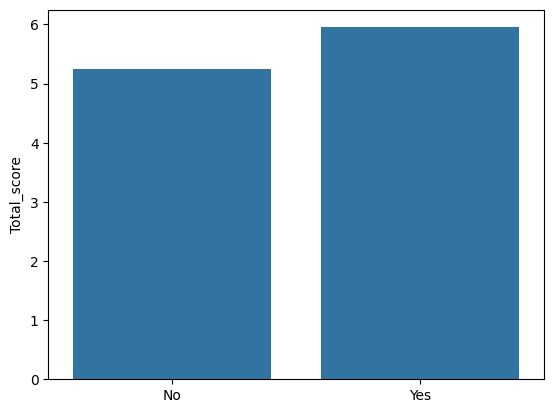

In [80]:
sns.barplot(x= df['Family_ASD'].unique(), y= df.groupby('Family_ASD')['Total_score'].mean())
plt.show()

The bar plot compares the average total scores of participants grouped by their family history of Autism Spectrum Disorder (ASD). The "Yes" bar represents individuals with a family history of ASD, while the "No" bar represents those without such a history.

The average total score is higher for individuals with a family history of ASD compared to those without.

This suggests a possible association between having a family member with ASD and scoring higher on the measured symptom or trait (as represented by the "Total_score").

# Compare the KDE curves of Total_Score for ASD vs non-ASD classes.


<Axes: xlabel='Total_score', ylabel='Density'>

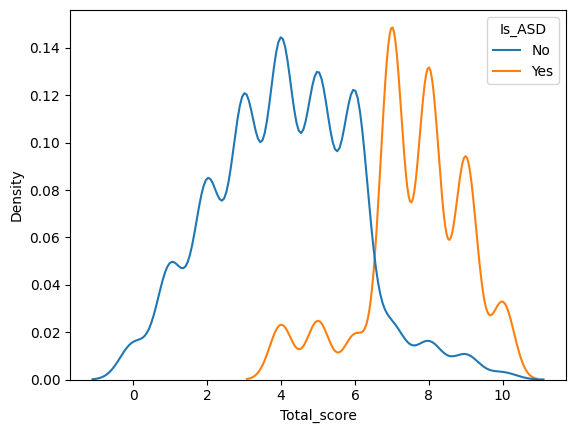

In [81]:
sns.kdeplot(x= df['Total_score'], hue = df['Is_ASD'])

The KDE plot shows that individuals diagnosed with ASD ("Yes") tend to have higher total scores, while those without ASD ("No") mostly have lower total scores. There is a clear separation, indicating that total score is effective at distinguishing between ASD and non-ASD groups.

#What is the age group (e.g., <10, 10–14, 15–20, >20) distribution?

In [82]:
# Define age bins and labels
bins = [0, 10, 15, 21, float('inf')]
labels = ['<10', '10–14', '15–20', '>20']

# Create a new column with age groups
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Calculate the distribution of age groups
age_group_distribution = df['Age_Group'].value_counts()

print(age_group_distribution)

Age_Group
>20      2447
<10      2119
15–20     708
10–14     512
Name: count, dtype: int64


This output shows how the individuals in the dataset are distributed across the defined age groups:

The largest age group is ">20" with 2447 individuals.

The second largest is "<10" with 2119 individuals.

The "15–20" age group has 708 individuals.

The "10–14" age group has 512 individuals.

This indicates that the dataset contains a substantial number of individuals in both younger (under 10) and older (over 20) age ranges, with fewer individuals in the adolescent years (10-20).

#Is there any pattern in total score across age groups?

In [83]:
total_score_by_age_group = df.groupby('Age_Group')['Total_score'].mean()

print("Average Total Score by Age Group:",total_score_by_age_group)

Average Total Score by Age Group: Age_Group
<10      5.724398
10–14    6.140625
15–20    5.132768
>20      4.994687
Name: Total_score, dtype: float64


The output shows the average total screening score for each age group:

<10: 5.72

10–14: 6.14

15–20: 5.13

and >20: 4.994

We can observe that the average total score is highest in the 10-14 age group and tends to decrease in older age groups. This suggests there might be a pattern in screening scores across different age ranges.

# How many individuals aged between 10 and 18 have ASD?

In [84]:
asd_between_10_and_18 = df[(df['Age'] >= 10) & (df['Age'] <= 18) & (df['Is_ASD'] == 'Yes')]

count_asd_between_10_and_18 = len(asd_between_10_and_18)

print(f"Number of individuals aged between 10 and 18 with ASD: {count_asd_between_10_and_18}")

Number of individuals aged between 10 and 18 with ASD: 415


#Among people with Yes in Family_ASD, how many are Class = Yes?

In [85]:
family_asd_and_ASD_yes = df[(df['Family_ASD'] == 'Yes') & (df['Is_ASD'] == 'Yes')]

count_family_asd_and_ASD_yes = len(family_asd_and_ASD_yes)

print(f"Number of individuals with Family_ASD 'Yes' and ASD 'Yes': {count_family_asd_and_ASD_yes}")

Number of individuals with Family_ASD 'Yes' and ASD 'Yes': 511


#Group by Sex and ASD(Yes/No) — what’s the ASD diagnosis rate per gender?

In [86]:
diagnosis_rate_by_gender = df.groupby('Sex')['Is_ASD'].value_counts(normalize=True).unstack() * 100

print(diagnosis_rate_by_gender)

Is_ASD         No        Yes
Sex                         
f       64.157256  35.842744
m       63.240059  36.759941


The output shows the percentage of individuals diagnosed with ASD within each gender group:

For females ('f'), approximately 35.84% have an ASD diagnosis ('Yes'), and 64.16% do not ('No'). For males ('m'), approximately 36.76% have an ASD diagnosis ('Yes'), and 63.24% do not ('No'). This indicates that the proportion of individuals diagnosed with ASD is very similar for both males and females in this dataset.

# Display a count plot showing the distribution of Sex.

<Axes: xlabel='Sex', ylabel='count'>

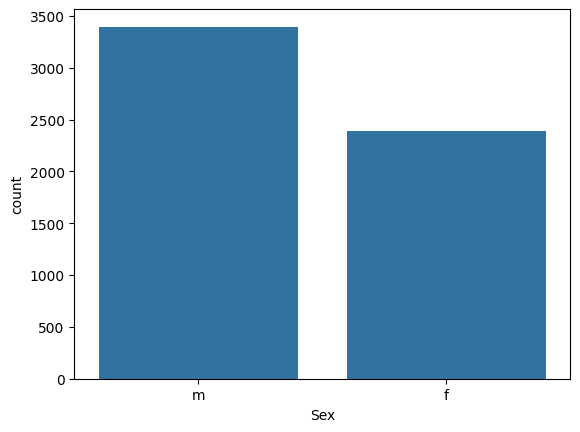

In [87]:
sns.countplot(x = df['Sex'])

The count plot shows that there are more males ('m') than females ('f') in the dataset, indicating a higher representation of males compared to females.

# Generate a count plot to visualize the frequency of each ASD(Yes/No) label

<Axes: xlabel='Is_ASD', ylabel='count'>

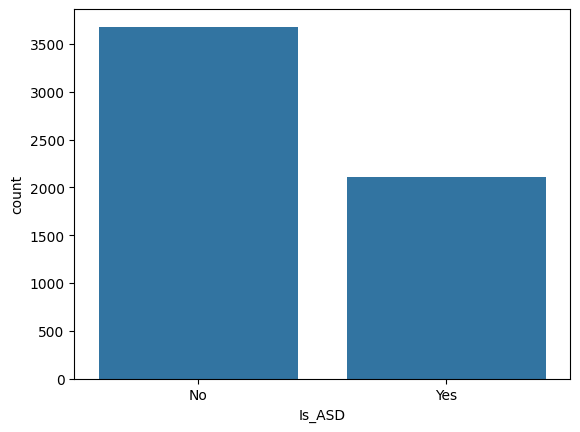

In [88]:
sns.countplot(x = df['Is_ASD'])

The plot shows that there are more individuals labeled as "No" (not ASD) than "Yes" (ASD) in the dataset, indicating that non-ASD cases are more frequent.

# Plot a violin graph comparing Total_Score distribution across genders.

<Axes: xlabel='Sex', ylabel='Total_score'>

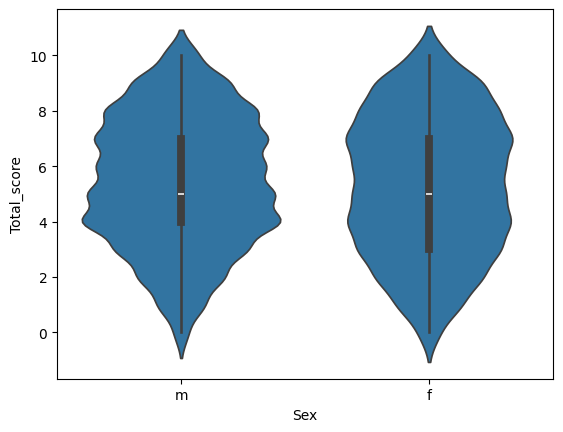

In [89]:
sns.violinplot(x = df['Sex'], y= df['Total_score'])

The violin plot shows that the distribution of Total_Score is very similar for both males ('m') and females ('f'), with both genders having comparable ranges and central tendencies in their scores. There is no significant difference in Total_Score distribution between genders.

# Draw a box plot to compare total screening scores between ASD and non-ASD groups.

<Axes: xlabel='Is_ASD', ylabel='Total_score'>

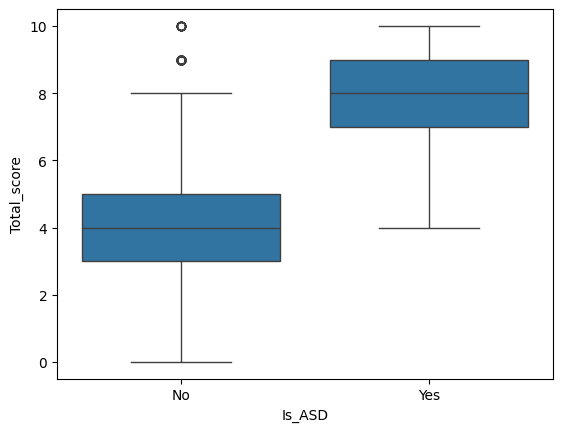

In [90]:
sns.boxplot(x= df['Is_ASD'], y = df['Total_score'])

The box plot shows that individuals with ASD ("Yes") have significantly higher total screening scores compared to non-ASD ("No") individuals. The distributions have minimal overlap, indicating that total score differentiates well between the two groups.

# Visualize age distribution by jaundice status using a violin plot.

<Axes: xlabel='Jaundice', ylabel='Age'>

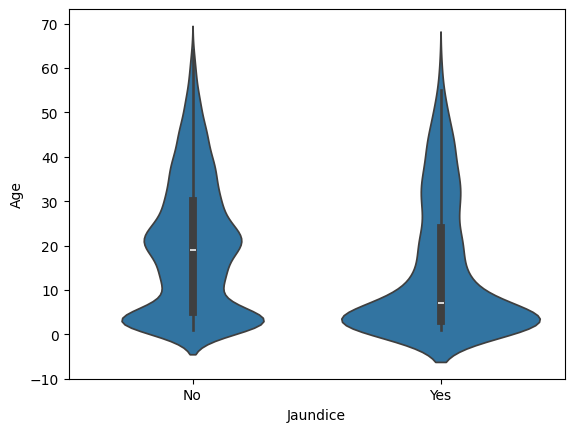

In [91]:
sns.violinplot(x = df['Jaundice'], y =df['Age'])

The violin plot shows that individuals with and without a history of jaundice have similar age distributions, though the "Yes" group (jaundice) appears to have a slightly lower median age. Both groups have a wide range of ages, but jaundice cases are more concentrated at younger ages.

# Display a grouped bar plot to compare ASD diagnosis rates across genders.



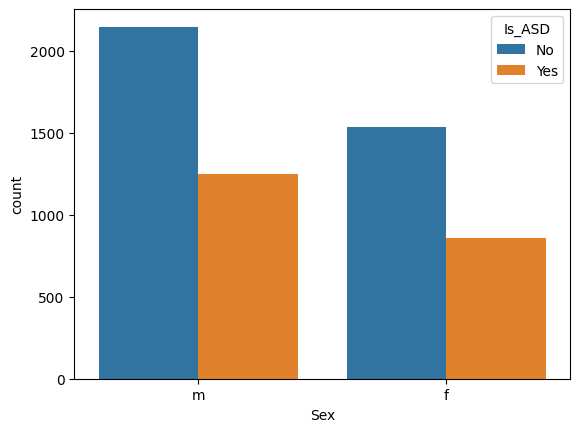

In [92]:
sns.countplot(x='Sex', hue='Is_ASD', data=df)
plt.show()

The grouped bar plot shows that males have higher counts of both ASD ("Yes") and non-ASD ("No") diagnoses compared to females. However, ASD diagnoses are more common among males than females, indicating a higher ASD prevalence in the male group.

# Generate a boxen plot to analyze age by gender

<Axes: xlabel='Sex', ylabel='Age'>

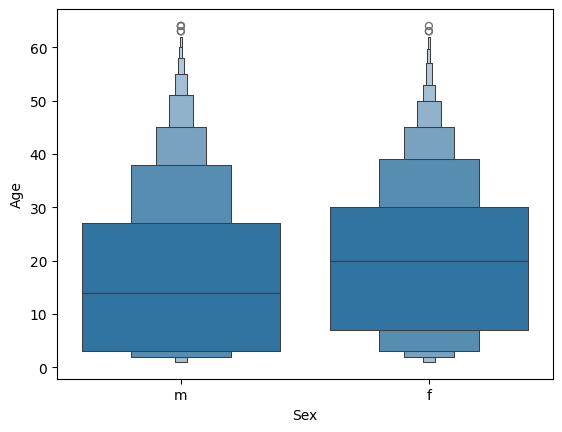

In [93]:
sns.boxenplot(x= df['Sex'], y = df['Age'])

Age distributions for males and females are very similar.

Both genders have a wide age range, with most values in younger ages.

Median ages are almost the same for males and females.

Both distributions have a few older outliers.

The spread and shape of the distributions do not show any major differences between genders.

# Use a catplot to visualize ASD distribution across both Sex and Family_ASD

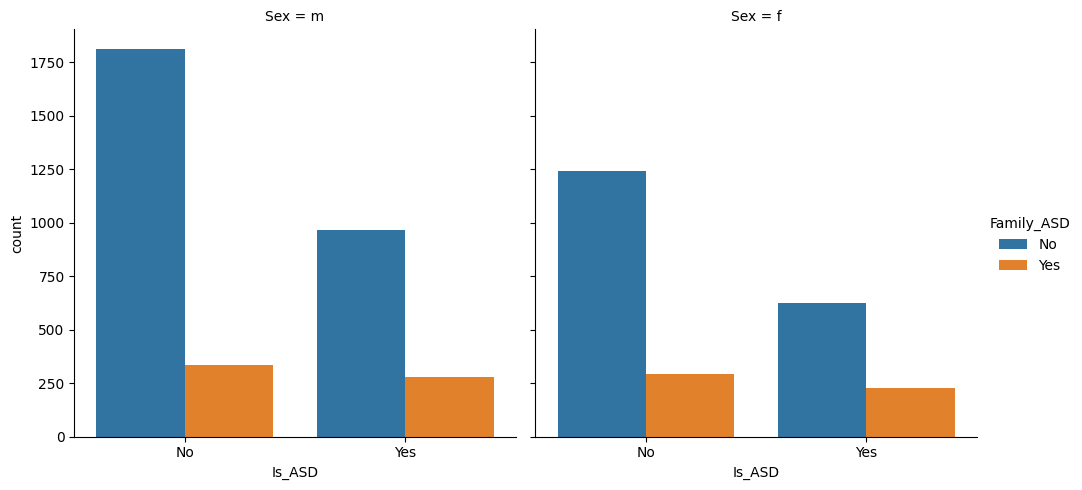

In [94]:
sns.catplot(x='Is_ASD', hue='Family_ASD', kind='count', data=df, col='Sex')

For both males and females, individuals without ASD are more numerous than those with ASD.

Having a family history of ASD ("Family_ASD" = Yes) is associated with higher ASD counts in both genders.

Among both sexes, those with a family history of ASD have a higher proportion of ASD diagnoses compared to those without.

Males have higher overall counts in each category compared to females, consistent with previous plots.

The pattern holds across sexes: family ASD history increases the ASD diagnosis rate, but the "No" group (no ASD) is always the largest in every subgroup.

# Plot a FacetGrid of ASD distribution for each gender, Jaundice, Family_ASD.

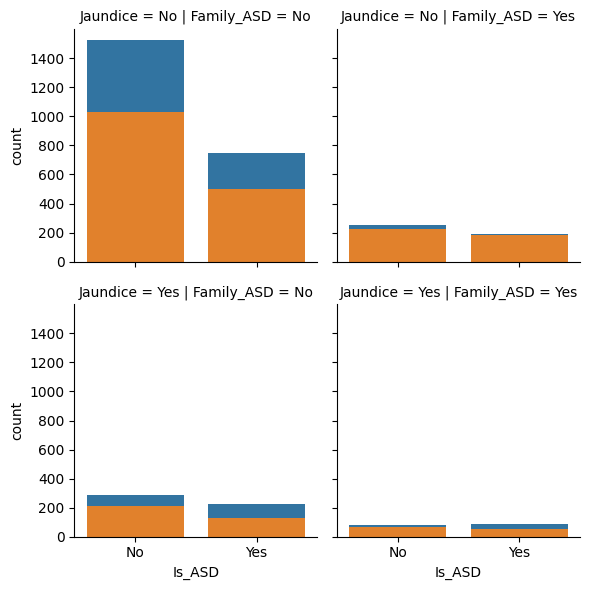

In [95]:
g = sns.FacetGrid(df, row= 'Jaundice', col= 'Family_ASD', hue = 'Sex')
g.map(sns.countplot, 'Is_ASD')

The largest group is individuals without jaundice and without a family history of ASD, with more ASD "No" cases than "Yes" and higher counts for males.

For those with a family history of ASD, the ASD "Yes" group becomes comparatively larger, especially among males.

Having jaundice reduces the overall count in all categories, but the general trend—higher ASD "Yes" cases with family ASD history—remains.

Both jaundice and family ASD history together decrease total counts but proportionally increase ASD "Yes" cases.

For every subgroup, the male count is higher than the female count.

Across all plots, a family history of ASD is associated with a higher number of ASD cases, regardless of jaundice or gender.

# Plot a KDE graph of age for ASD vs non-ASD across genders.



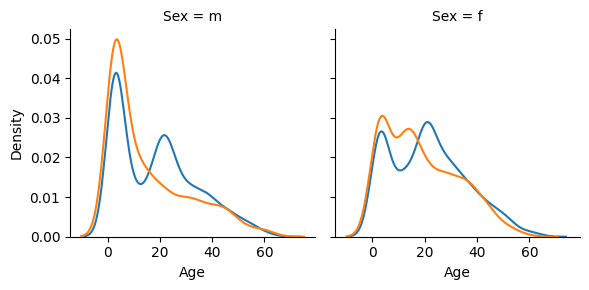

In [96]:
g= sns.FacetGrid(df, col = 'Sex', hue = 'Is_ASD')
g.map(sns.kdeplot, 'Age')

For both males and females, the majority of ASD and non-ASD individuals are younger, with density peaking at lower ages.

Among males, ASD (orange line) is slightly more concentrated at younger ages compared to non-ASD (blue line).

Among females, the age distributions of ASD and non-ASD are quite similar, with only minor differences in density peaks.

Across both genders, ASD and non-ASD cases span a wide age range, but are predominantly more frequent in younger age groups.

# Use a point plot to visualize gender differences in screening question averages.

<Axes: xlabel='Sex', ylabel='average_score'>

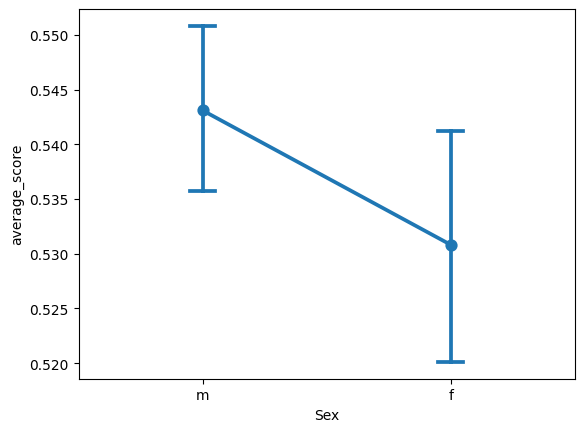

In [97]:
df['average_score'] = df[questions].mean(axis=1)
sns.pointplot(data=df, x='Sex', y='average_score', capsize=0.1)

The point plot shows that males have a slightly higher average screening score than females. However, the difference between genders is small, and the error bars suggest some overlap in score variability. This indicates only a minor gender difference in screening question averages.

# Aggregate A1–A10 scores by age group and visualize their mean with a bar


<Axes: xlabel='Age_Group', ylabel='average_score'>

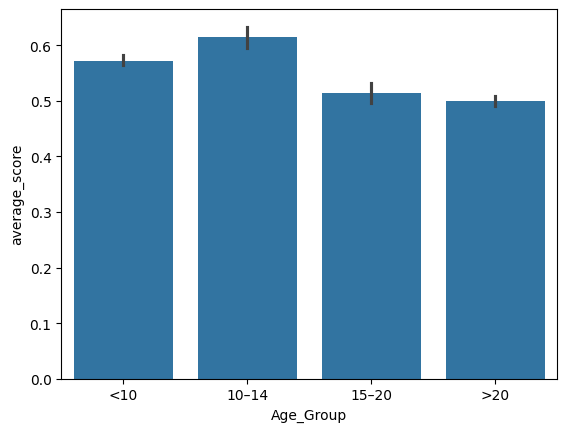

In [98]:
age_group_means = df.groupby('Age_Group')['average_score'].mean().reset_index()
sns.barplot(data=df, x='Age_Group', y='average_score')

The bar plot shows that the average A1–A10 scores are highest in the 10–14 age group, followed by the <10 group. Average scores decrease in older age groups (15–20 and >20), indicating that younger participants tend to have higher screening question averages compared to older participants.

# Plot a heatmap of Jaundice and Family_ASD combinations.



<Axes: xlabel='Family_ASD', ylabel='Jaundice'>

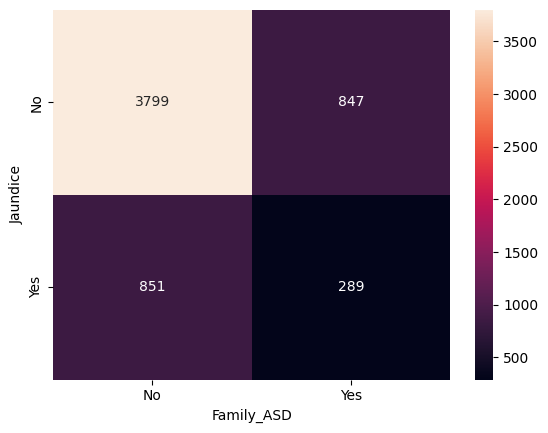

In [99]:
pivot_table = df.pivot_table(index = 'Jaundice', columns = 'Family_ASD', values = 'Is_ASD', aggfunc= 'count')
sns.heatmap(pivot_table, annot = True, fmt = 'd')

The heatmap shows that the most common combination is individuals without jaundice and no family history of ASD. The least common group is those with both jaundice and a family history of ASD. In both jaundice categories, having a family ASD history is less frequent than not having one. This highlights that most of the dataset is concentrated in the "No Jaundice, No Family_ASD" category.

# Bin ages into ranges and display the ASD count per bin

<Axes: xlabel='Is_ASD', ylabel='count'>

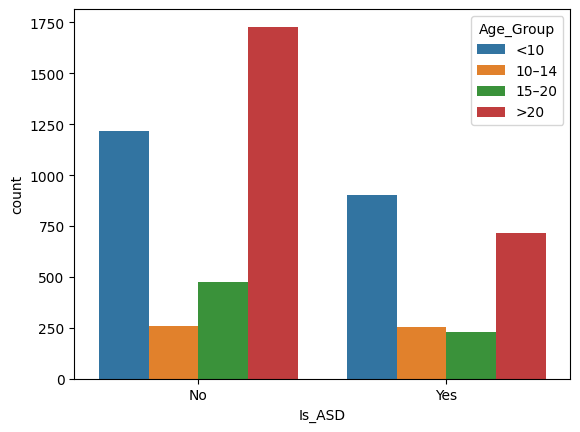

In [100]:
sns.countplot(x = df['Is_ASD'], hue = df['Age_Group'])

The bar plot shows that the youngest age group ("<10") has the highest count of ASD ("Yes") cases, while the oldest age group (">20") has the highest count of non-ASD ("No") cases. Younger age groups are more represented among ASD diagnoses, whereas older age groups are more common in the non-ASD group. This suggests ASD diagnoses are more frequent in children than in adults in this dataset.

# Use a line plot to examine average total scores across increasing ages

<Axes: xlabel='Age', ylabel='Total_score'>

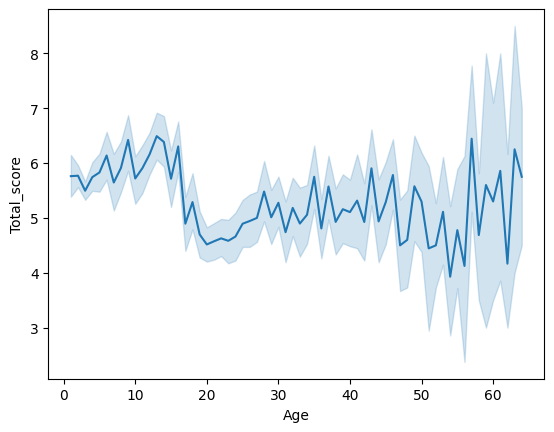

In [101]:
sns.lineplot(x = df['Age'], y = df['Total_score'])


The line plot shows that average total scores are relatively higher in early childhood and tend to decrease slightly during adolescence and early adulthood. Scores remain fairly stable through most of adulthood, with greater variability (wider confidence intervals) at older ages due to fewer data points. Overall, younger individuals tend to have slightly higher average total scores.



# Compare ASD rates between males and females within each age group using grouped bars.

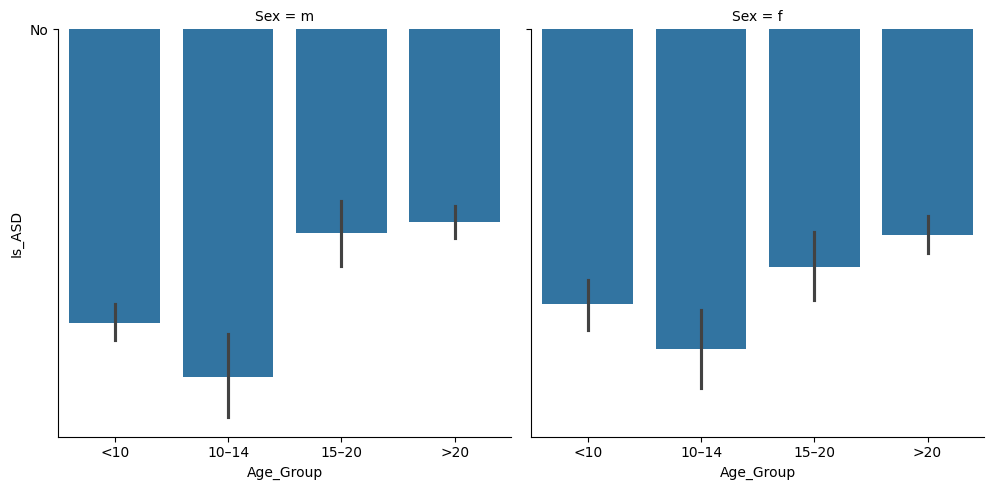

In [102]:
sns.catplot(
    data=df,
    kind="bar",
    x="Age_Group",
    y="Is_ASD",
    col="Sex",
    estimator=lambda x: sum(x)/len(x),
)

Across all age groups, males consistently have higher ASD rates than females.

In both males and females, the ASD rate appears to peak in the 10–14 age group and then slightly decreases in older groups.

The gap in ASD rates between males and females remains evident for each age group, confirming the well-documented trend that ASD is more frequently diagnosed in males.

Error bars suggest some variability, but the male–female difference is consistent regardless of age group.

Males show higher ASD rates than females in every age group, with the highest prevalence generally in the 10–14 age group for both sexes. This aligns with known epidemiological patterns for ASD.



In [103]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,Age,Sex,Jaundice,Family_ASD,Is_ASD,z_score,Total_score,Age_Norm,Age_Group,average_score
0,1,1,0,1,0,0,1,1,0,0,15,m,No,No,No,-0.257278,5,0.222222,15–20,0.5
1,0,1,1,1,0,1,1,0,1,0,15,m,No,No,No,-0.257278,6,0.222222,15–20,0.6
2,1,1,1,0,1,1,1,1,1,1,15,f,No,Yes,Yes,-0.257278,9,0.222222,15–20,0.9
3,1,1,1,1,1,1,1,1,0,0,16,f,No,No,Yes,-0.192103,8,0.238095,15–20,0.8
4,1,1,1,1,1,1,1,1,1,1,15,f,No,No,Yes,-0.257278,10,0.222222,15–20,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,2,m,No,Yes,Yes,-1.104554,4,0.015873,<10,0.4
7121,0,1,0,1,1,1,1,1,1,0,2,f,No,No,Yes,-1.104554,7,0.015873,<10,0.7
7122,1,1,0,0,1,1,1,0,0,0,2,f,No,No,Yes,-1.104554,5,0.015873,<10,0.5
7125,0,0,1,1,1,0,1,0,1,0,1,m,Yes,No,Yes,-1.169729,5,0.000000,<10,0.5


# Visualize the average Total_Score grouped by both Class and Sex.

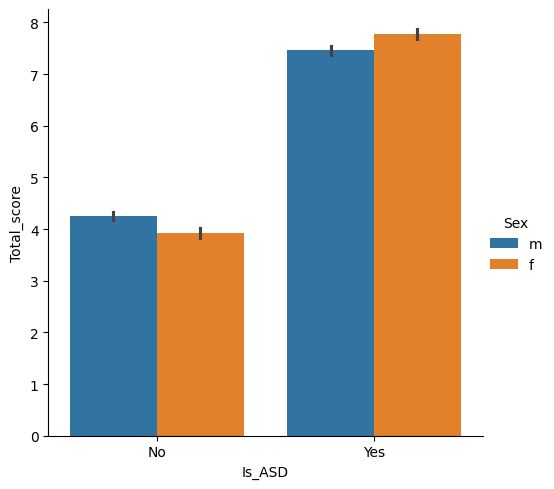

In [104]:
sns.catplot(df, x= 'Is_ASD', y= 'Total_score', hue = 'Sex', kind = 'bar')

Individuals diagnosed with ASD ("Yes") have higher average Total_Score than those without ASD ("No"), for both males and females.

Among individuals without ASD, males have a slightly higher average Total_Score than females.

Among those with ASD, females have a slightly higher average Total_Score than males.

The difference in Total_Score between ASD and non-ASD groups is substantial and consistent across both sexes.

Error bars are small, indicating low variability and that the differences are quite robust.

Average Total_Score is much higher for people with ASD, and while males without ASD outscore females, this pattern reverses in the ASD group, where females slightly outscore males. This suggests Total_Score is a strong marker for ASD, and there are subtle sex differences in both groups.

# Create a FacetGrid showing KDEs of Total_Score across different Sex values.

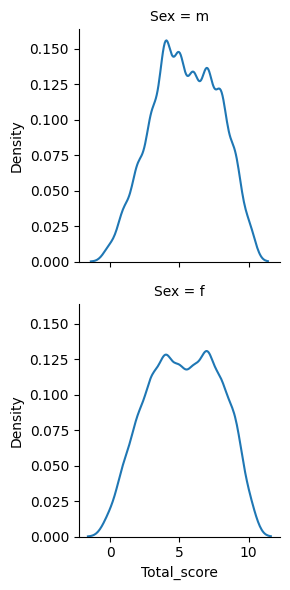

In [105]:
g = sns.FacetGrid(df, row= 'Sex')
g.map(sns.kdeplot, 'Total_score')

Distribution Shape: Both males and females show a roughly bell-shaped distribution of Total_Score, indicating most scores are clustered around the center with fewer at the extremes.

Peaks: The density peaks (modes) for both distributions appear between scores of roughly 4 and 7, suggesting these are the most common Total_Score values for both sexes.

Spread: The shape and spread of the distributions for males and females are quite similar, but subtle differences may exist in the location or height of the peaks.

Range: Both sexes have Total_Score values ranging from 0 up to about 10–11.

The KDE plots show that Total_Score has a similar overall distribution for males and females, with both distributions peaking around the same score range and spanning from 0 to approximately 10. Any differences between sexes are minor and primarily relate to slight variations in the density peaks.

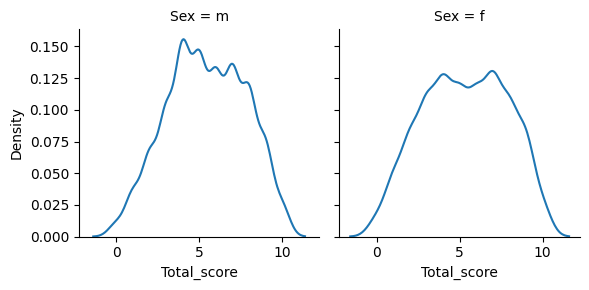

In [106]:
g = sns.FacetGrid(df, col= 'Sex')
g.map(sns.kdeplot, 'Total_score')

Overall Distribution: Both males (Sex = m) and females (Sex = f) have Total_Score distributions that are centered around similar values, mostly between 4 and 8.

Peaks and Spread:

The male distribution shows more pronounced small peaks or multimodalities, especially between scores 4 and 8.

The female distribution appears smoother and more symmetrically bell-shaped, also peaking around scores 4 to 8.

Range:
Both distributions span the full scoring range (0 to about 10–11), indicating a similar scoring range for both sexes.

Density:
The peak density values are slightly higher for males, but overall differences are subtle.


Both sexes have a similar range and central tendency in Total_Score, though the male distribution shows more fluctuation in density across scores, while the female distribution is smoother and more uniform. This suggests that, while Total_Score patterns are similar between sexes, males may display slightly more variability in how their scores are distributed.

# Use catplot(kind="bar") with col=Sex to show mean Total_Score per ASD Diagonosis.

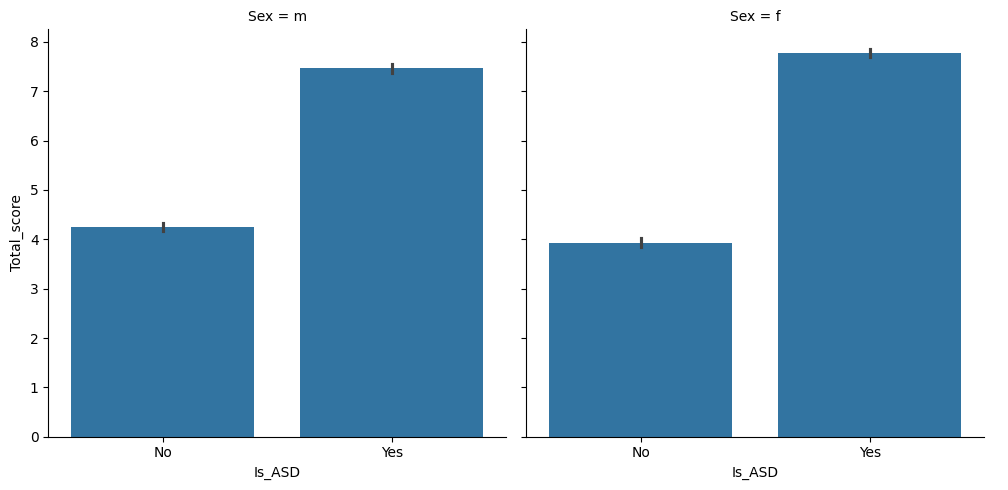

In [107]:
sns.catplot(data = df, kind = 'bar', x= 'Is_ASD', y= 'Total_score', col = 'Sex', estimator= 'mean')

For both sexes, individuals diagnosed with ASD ("Yes") have much higher mean Total_Score than those without ASD ("No").

The increase in mean Total_Score with ASD diagnosis is substantial and visually similar for both males and females.

Comparing between sexes:

Among those without ASD, males have a slightly higher mean Total_Score than females.

Among those with ASD, females have a slightly higher mean Total_Score than males.

Error bars are small, indicating that the estimates of the mean are precise and differences are robust.

ASD diagnosis is associated with a much higher mean Total_Score for both males and females. There is a small sex difference: males score higher in the non-ASD group, while females score slightly higher in the ASD group. This suggests that the relationship between Total_Score and ASD is strong and consistent across sexes, though subtle sex differences are present within each diagnostic group.

# Use FacetGrid to display bar charts of ASD cases grouped by Family_ASD and faceted by Sex.

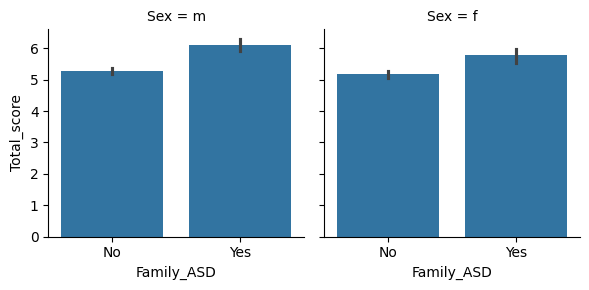

In [108]:
g = sns.FacetGrid(data = df, col = 'Sex')
g.map(sns.barplot,'Family_ASD','Total_score' )

Males: Those with a family history of ASD have higher average Total_scores than those without.

Females: The difference in Total_scores between those with or without a family ASD history is smaller.

Summary: Family history of ASD is linked to higher scores in both sexes, especially in males.

# Machine Learning

# One Hot Encoding


In [109]:
def one_hot_encoding(df, columns):
    encoded_df = pd.get_dummies(df[columns], drop_first=True)

    df = df.drop(columns=columns)

    df = pd.concat([df, encoded_df], axis=1)

    return df

In [110]:
df = one_hot_encoding(df, ['Age_Group'])

In [111]:
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Jaundice,Family_ASD,Is_ASD,z_score,Total_score,Age_Norm,average_score,Age_Group_10–14,Age_Group_15–20,Age_Group_>20
0,1,1,0,1,0,0,1,1,0,0,...,No,No,No,-0.257278,5,0.222222,0.5,False,True,False
1,0,1,1,1,0,1,1,0,1,0,...,No,No,No,-0.257278,6,0.222222,0.6,False,True,False
2,1,1,1,0,1,1,1,1,1,1,...,No,Yes,Yes,-0.257278,9,0.222222,0.9,False,True,False
3,1,1,1,1,1,1,1,1,0,0,...,No,No,Yes,-0.192103,8,0.238095,0.8,False,True,False
4,1,1,1,1,1,1,1,1,1,1,...,No,No,Yes,-0.257278,10,0.222222,1.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,...,No,Yes,Yes,-1.104554,4,0.015873,0.4,False,False,False
7121,0,1,0,1,1,1,1,1,1,0,...,No,No,Yes,-1.104554,7,0.015873,0.7,False,False,False
7122,1,1,0,0,1,1,1,0,0,0,...,No,No,Yes,-1.104554,5,0.015873,0.5,False,False,False
7125,0,0,1,1,1,0,1,0,1,0,...,Yes,No,Yes,-1.169729,5,0.000000,0.5,False,False,False


Define helper (one_hot_encoding)

Uses pd.get_dummies(..., drop_first=True) to one-hot encode chosen categorical columns.

Drops the original categorical columns and concatenates the new dummy columns.

Returns the updated DataFrame.

Apply helper

Calls one_hot_encoding(df, ['Age_Group']).

Replaces Age_Group with three binary columns: Age_Group_10–14, Age_Group_15–20, Age_Group_>20.

Produces a model-ready DataFrame containing only numeric features.

# Rename Columns

In [112]:
df.rename(columns = {'Sex_m': 'Male', 'Jaundice_Yes': 'Jaundice', 'Is_ASD_Yes': 'Is_ASD', 'Family_ASD_Yes':'Family_ASD'}, inplace = True)
df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Jaundice,Family_ASD,Is_ASD,z_score,Total_score,Age_Norm,average_score,Age_Group_10–14,Age_Group_15–20,Age_Group_>20
0,1,1,0,1,0,0,1,1,0,0,...,No,No,No,-0.257278,5,0.222222,0.5,False,True,False
1,0,1,1,1,0,1,1,0,1,0,...,No,No,No,-0.257278,6,0.222222,0.6,False,True,False
2,1,1,1,0,1,1,1,1,1,1,...,No,Yes,Yes,-0.257278,9,0.222222,0.9,False,True,False
3,1,1,1,1,1,1,1,1,0,0,...,No,No,Yes,-0.192103,8,0.238095,0.8,False,True,False
4,1,1,1,1,1,1,1,1,1,1,...,No,No,Yes,-0.257278,10,0.222222,1.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,...,No,Yes,Yes,-1.104554,4,0.015873,0.4,False,False,False
7121,0,1,0,1,1,1,1,1,1,0,...,No,No,Yes,-1.104554,7,0.015873,0.7,False,False,False
7122,1,1,0,0,1,1,1,0,0,0,...,No,No,Yes,-1.104554,5,0.015873,0.5,False,False,False
7125,0,0,1,1,1,0,1,0,1,0,...,Yes,No,Yes,-1.169729,5,0.000000,0.5,False,False,False



Rename columns in df

Sex_m ➜ Male

Jaundice_Yes ➜ Jaundice

Is_ASD_Yes ➜ Is_ASD

Family_ASD_Yes ➜ Family_ASD

Done in-place (inplace=True), so no new DataFrame is created.

# Feature Scaling

In [113]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
scaler = MinMaxScaler()
scaler1 = StandardScaler()
df['Age_norm']=scaler.fit_transform(df[['Age']])
df['Age_standard']=scaler1.fit_transform(df[['Age']])

df

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,...,Is_ASD,z_score,Total_score,Age_Norm,average_score,Age_Group_10–14,Age_Group_15–20,Age_Group_>20,Age_norm,Age_standard
0,1,1,0,1,0,0,1,1,0,0,...,No,-0.257278,5,0.222222,0.5,False,True,False,0.222222,-0.249173
1,0,1,1,1,0,1,1,0,1,0,...,No,-0.257278,6,0.222222,0.6,False,True,False,0.222222,-0.249173
2,1,1,1,0,1,1,1,1,1,1,...,Yes,-0.257278,9,0.222222,0.9,False,True,False,0.222222,-0.249173
3,1,1,1,1,1,1,1,1,0,0,...,Yes,-0.192103,8,0.238095,0.8,False,True,False,0.238095,-0.182621
4,1,1,1,1,1,1,1,1,1,1,...,Yes,-0.257278,10,0.222222,1.0,False,True,False,0.222222,-0.249173
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7114,0,0,0,0,1,1,1,0,1,0,...,Yes,-1.104554,4,0.015873,0.4,False,False,False,0.015873,-1.114347
7121,0,1,0,1,1,1,1,1,1,0,...,Yes,-1.104554,7,0.015873,0.7,False,False,False,0.015873,-1.114347
7122,1,1,0,0,1,1,1,0,0,0,...,Yes,-1.104554,5,0.015873,0.5,False,False,False,0.015873,-1.114347
7125,0,0,1,1,1,0,1,0,1,0,...,Yes,-1.169729,5,0.000000,0.5,False,False,False,0.000000,-1.180899


# Column Transformer

In [114]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
scaler = MinMaxScaler()
scaler1 = StandardScaler()
ohe = OneHotEncoder(drop = 'first', handle_unknown= 'ignore')

In [115]:
categorical_features = ['Sex', 'Jaundice', 'Is_ASD', 'Family_ASD']
categorical_features_1 = ['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Sex',
 'Jaundice',
 'Family_ASD']
numerical_features = ['Age']

In [116]:
from sklearn.compose import ColumnTransformer

preprocessor_1 = ColumnTransformer(
    transformers= [
        ('cat', ohe, categorical_features_1),
        ('num', scaler1, numerical_features)
    ]
)

Import scalers

MinMaxScaler (0–1 normalization) and StandardScaler (z-score standardization) from sklearn.preprocessing.

Instantiate scalers

scaler = MinMaxScaler()

scaler1 = StandardScaler()

Create two new age features

Age_norm – min-max–scaled age values: each entry scaled to the
0
,
1
0,1 range using scaler.fit_transform(df[['Age']]).

Age_standard – z-score–standardised age values: mean 0, variance 1 using scaler1.fit_transform(df[['Age']]).

Update DataFrame

Both new columns are added directly to df; printing df confirms their presence alongside existing features.

# Logistic Regression

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

clf_1 = Pipeline(
    steps = [
      ('preprocessing', preprocessor_1),
      ('fitting', model)
    ]
)


In [118]:
df.columns.tolist()

['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Age',
 'Sex',
 'Jaundice',
 'Family_ASD',
 'Is_ASD',
 'z_score',
 'Total_score',
 'Age_Norm',
 'average_score',
 'Age_Group_10–14',
 'Age_Group_15–20',
 'Age_Group_>20',
 'Age_norm',
 'Age_standard']

In [119]:
from sklearn.model_selection import train_test_split

x = df[['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Sex',
 'Jaundice',
 'Family_ASD',
 'Age']]

y = df['Is_ASD']
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.2, random_state= 42)

In [120]:
clf_1.fit(X_train,Y_train)

,steps,"[('preprocessing', ...), ('fitting', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [121]:
Y_pred = clf_1.predict(X_test)

In [122]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, Y_pred)

0.8894645941278065

Pipeline assembly: combines preprocessor_1 (one-hot encoding of A1–A10 + Sex/Jaundice/Family_ASD and z-score scaling of Age) with a default LogisticRegression classifier, forming clf_1.

Feature/target selection: X = 14 predictors (A1–A10, Sex, Jaundice, Family_ASD, Age); y = binary label Is_ASD.

Data split: train_test_split creates 80% train and 20% test sets with random_state=42 for reproducibility.

Training & inference: clf_1.fit learns both preprocessing parameters and logistic-regression weights on the training data; clf_1.predict then outputs ASD predictions (Y_pred) for the unseen test set.

# Confusion Matrix

In [123]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(Y_pred, Y_test)

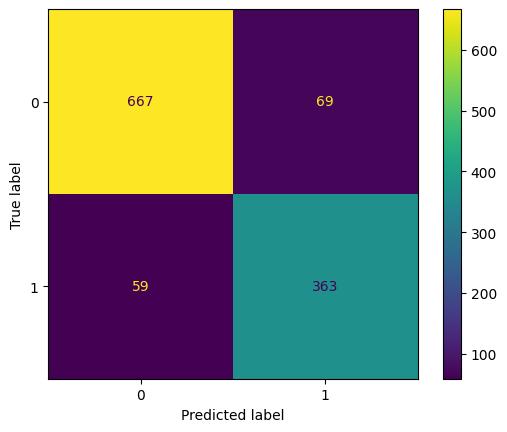

In [124]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Generate confusion matrix: confusion_matrix(Y_pred, Y_test) creates a 2×2 matrix showing true vs predicted ASD classifications (note: correct parameter order is Y_test, Y_pred).

Display visualization: ConfusionMatrixDisplay wraps the matrix and disp.plot() creates a labeled heatmap showing True Negative, False Positive, False Negative, and True Positive counts.

Purpose: Visual evaluation of model performance—diagonal entries = correct predictions, off-diagonal = classification errors; helps assess precision, recall, and overall accuracy of the ASD screening model.

# Using GridSearchCV for making multiple classification models for prediction


In [125]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from IPython.display import display

In [126]:
df['Is_ASD'].value_counts()

Is_ASD
No     3681
Yes    2105
Name: count, dtype: int64

In [127]:
from sklearn.model_selection import train_test_split

x = df[['A1',
 'A2',
 'A3',
 'A4',
 'A5',
 'A6',
 'A7',
 'A8',
 'A9',
 'A10',
 'Sex',
 'Jaundice',
 'Family_ASD',
 'Age']]

y = df['Is_ASD']
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size = 0.2,stratify = y, random_state= 42)

In [128]:
models_params = [
    {
        'name': 'Logistic Regression',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', LogisticRegression())]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__solver': ['liblinear']
        }
    },
    {
        'name': 'Random Forest',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', RandomForestClassifier())]),
        'params': {
            'clf__n_estimators': [50, 100],
            'clf__max_depth': [None, 10, 20]
        }
    },
    {
        'name': 'Support Vector Machine',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', SVC())]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf']
        }
    },
    {
        'name': 'K-Nearest Neighbors',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', KNeighborsClassifier())]),
        'params': {
            'clf__n_neighbors': [3, 5, 7]
        }
    },
    {
        'name': 'Decision Tree',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', DecisionTreeClassifier())]),
        'params': {
            'clf__max_depth': [None, 5, 10]
        }
    },
    {
        'name': 'Naive Bayes',
        'pipeline': Pipeline([('preprocessing', preprocessor_1), ('clf', GaussianNB())]),
        'params': {}
    }
]


Running GridSearchCV for: Logistic Regression


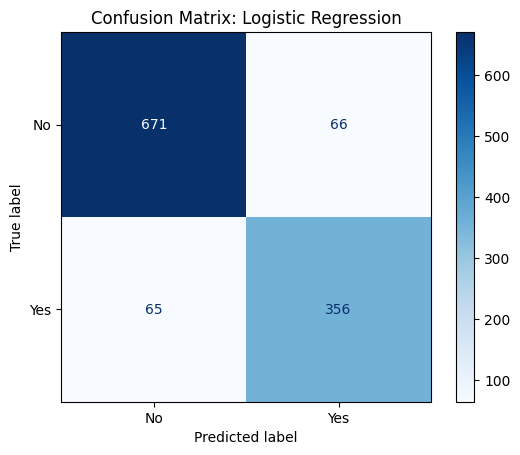


Running GridSearchCV for: Random Forest


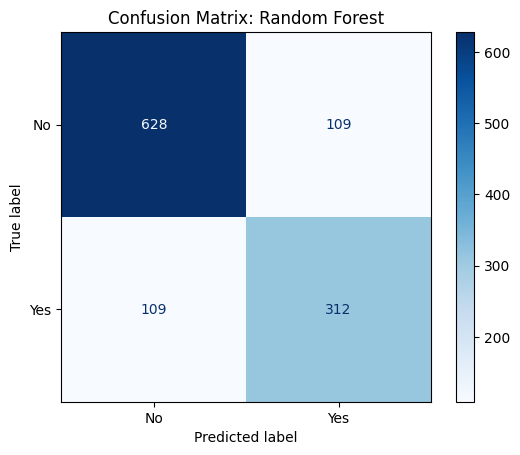


Running GridSearchCV for: Support Vector Machine


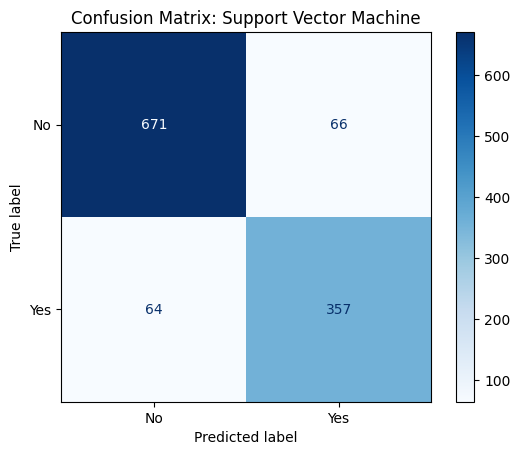


Running GridSearchCV for: K-Nearest Neighbors


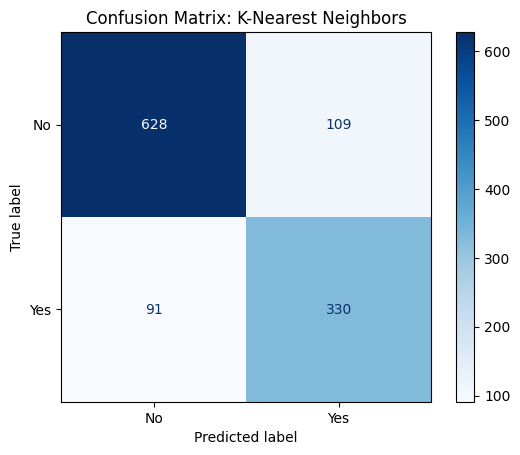


Running GridSearchCV for: Decision Tree


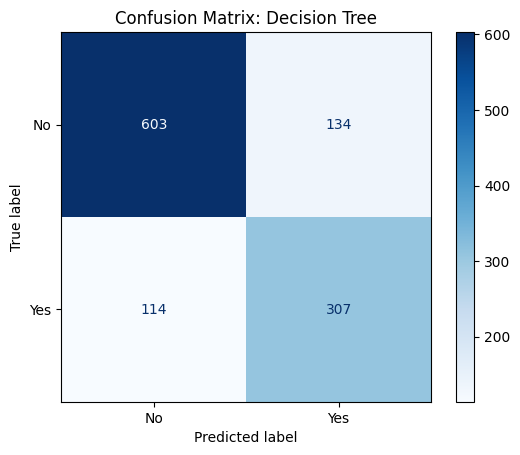


Running GridSearchCV for: Naive Bayes


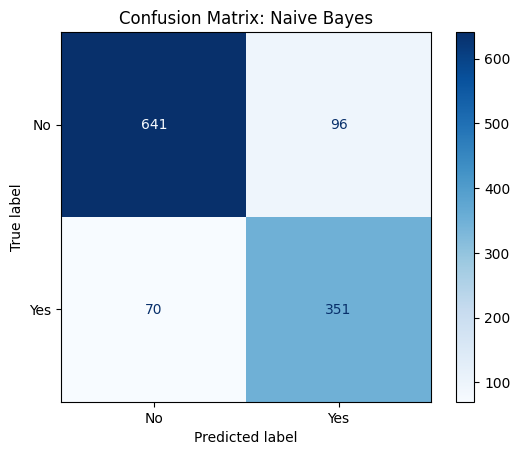

In [129]:
results = []
for model_info in models_params:
    name = model_info['name']
    pipeline = model_info['pipeline']
    param_grid = model_info['params']
    print(f"\nRunning GridSearchCV for: {name}")

    if param_grid:
        gs = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')
        gs.fit(X_train, Y_train)
        best_params = gs.best_params_
        best_cv_score = gs.best_score_
        best_model = gs.best_estimator_
    else:
        best_model = pipeline.fit(X_train, Y_train)
        best_params = "Default"
        best_cv_score = best_model.score(X_train, Y_train)
    test_score = best_model.score(X_test, Y_test)

    Y_pred = best_model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    results.append({
        'Model': name,
        'Best Params': best_params,
        'CV Accuracy': round(best_cv_score, 3),
        'Test Accuracy': round(test_score, 3)
    })


Summary Table:
                    Model                                       Best Params  \
0  Support Vector Machine          {'clf__C': 0.1, 'clf__kernel': 'linear'}   
1     Logistic Regression        {'clf__C': 10, 'clf__solver': 'liblinear'}   
2             Naive Bayes                                           Default   
3     K-Nearest Neighbors                           {'clf__n_neighbors': 7}   
4           Random Forest  {'clf__max_depth': 10, 'clf__n_estimators': 100}   
5           Decision Tree                             {'clf__max_depth': 5}   

   CV Accuracy  Test Accuracy  
0        0.902          0.888  
1        0.899          0.887  
2        0.868          0.857  
3        0.839          0.827  
4        0.831          0.812  
5        0.807          0.786  


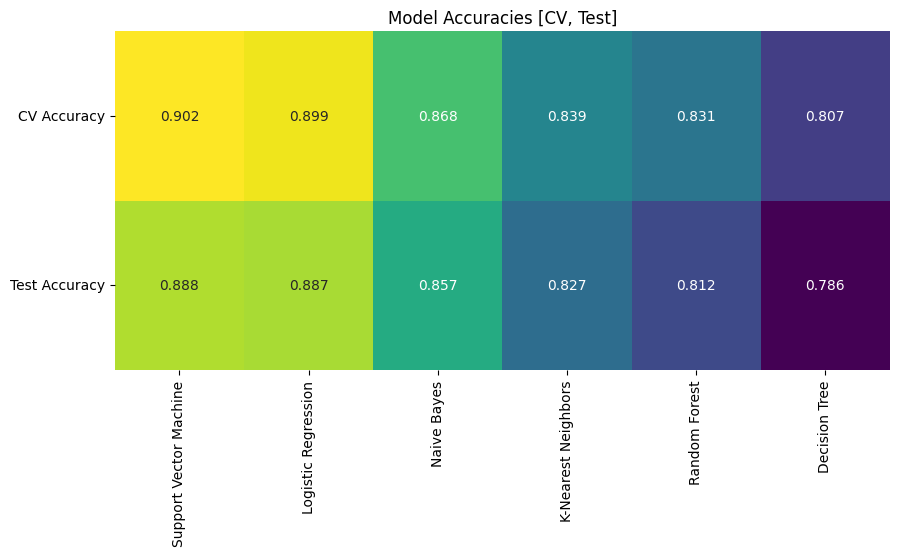

In [130]:
df_results = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
print('\nSummary Table:')
print(df_results)

plt.figure(figsize=(10,2+0.4*len(df_results)))
sns.heatmap(df_results[['CV Accuracy','Test Accuracy']].T,
            annot=df_results[['CV Accuracy', 'Test Accuracy']].T,
            cmap='viridis', cbar=False, fmt='.3f',
            xticklabels=df_results['Model'])
plt.title("Model Accuracies [CV, Test]")
plt.yticks(rotation=0)
plt.show()

Model comparison framework: Defines 6 machine learning algorithms (Logistic Regression, Random Forest, SVM, KNN, Decision Tree, Naive Bayes) each paired with the same preprocessor_1 pipeline.

Hyperparameter tuning: Uses GridSearchCV with 5-fold cross-validation to find optimal parameters for each model—C values for regularization, tree depths, neighbor counts, kernel types, etc.

Performance evaluation: For each model, records best hyperparameters, cross-validation accuracy, and test set accuracy; generates confusion matrices with blue color scheme for visual assessment.

Results compilation: Creates a summary DataFrame (df_results) sorted by test accuracy and produces a heatmap visualization comparing CV vs test accuracies across all models to identify the best-performing ASD classifier.

# Using undersampling and oversampling for more accuracy

In [131]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
models_params = [
    {
        'name': 'Logistic Regression',
        'pipeline': Pipeline([
            ('preprocessing', preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', LogisticRegression(max_iter=1000))
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__solver': ['liblinear']
        }
    },
    {
        'name': 'Random Forest',
        'pipeline': Pipeline([
            ('preprocessing', preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', RandomForestClassifier(random_state=42))
        ]),
        'params': {
            'clf__n_estimators': [50, 100],
            'clf__max_depth': [None, 10, 20]
        }
    },
    {
        'name': 'Support Vector Machine',
        'pipeline': Pipeline([
            ('preprocessing',preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', SVC())
        ]),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf']
        }
    },
    {
        'name': 'K-Nearest Neighbors',
        'pipeline': Pipeline([
            ('preprocessing', preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', KNeighborsClassifier())
        ]),
        'params': {
            'clf__n_neighbors': [3, 5, 7]
        }
    },
    {
        'name': 'Decision Tree',
        'pipeline': Pipeline([
            ('preprocessing', preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', DecisionTreeClassifier(random_state=42))
        ]),
        'params': {
            'clf__max_depth': [None, 5, 10]
        }
    },
    {
        'name': 'Naive Bayes',
        'pipeline': Pipeline([
            ('preprocessing', preprocessor_1),
            ('smote', SMOTE(random_state=42)),
            ('under', RandomUnderSampler(random_state=42)),
            ('clf', GaussianNB())
        ]),
        'params': {}
    }
]



NameError: name 'SMOTE' is not defined


Running GridSearchCV for: Logistic Regression


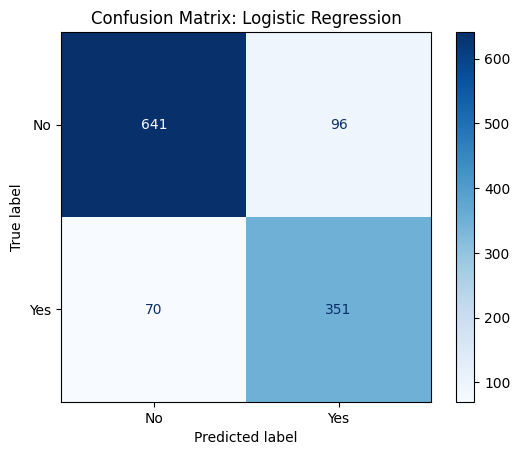


Running GridSearchCV for: Random Forest


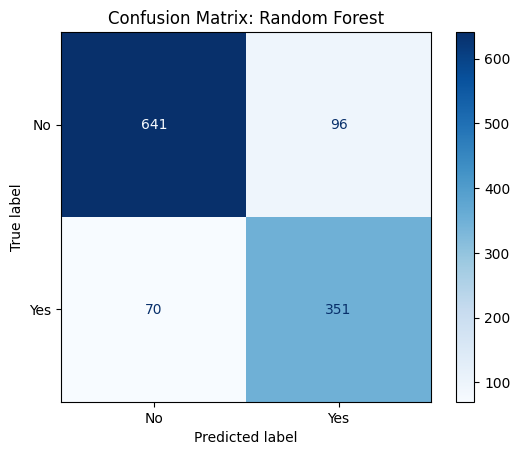


Running GridSearchCV for: Support Vector Machine


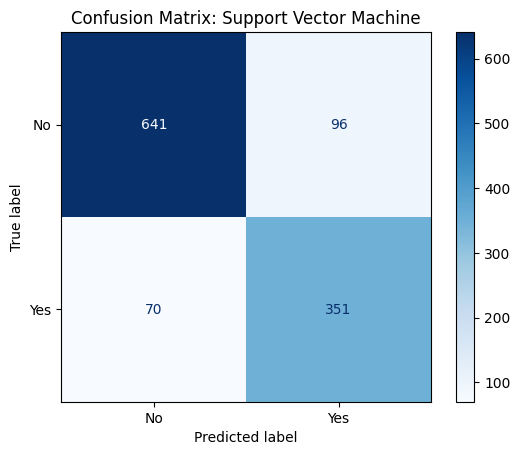


Running GridSearchCV for: K-Nearest Neighbors


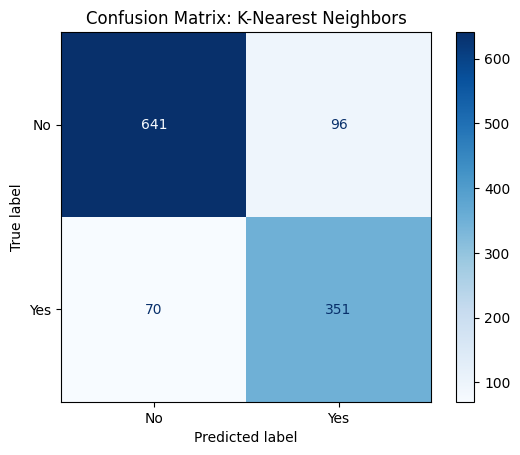


Running GridSearchCV for: Decision Tree


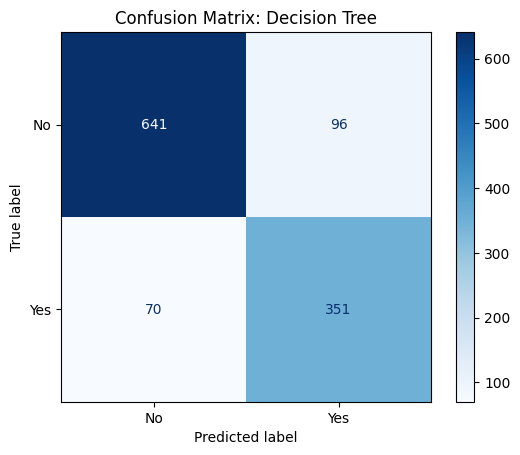


Running GridSearchCV for: Naive Bayes


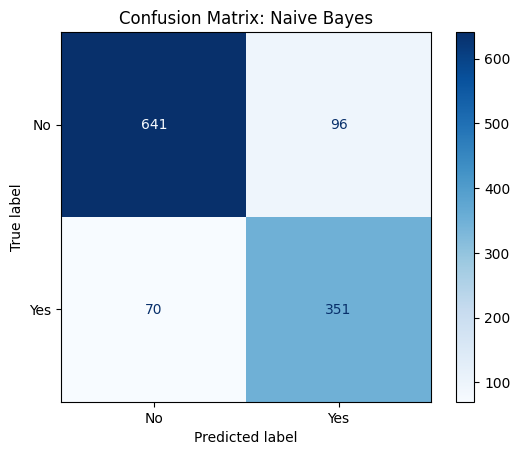

In [ ]:
results = []
for model_info in models_params:
    name = model_info['name']
    pipeline = model_info['pipeline']
    param_grid = model_info['params']
    print(f"\nRunning GridSearchCV for: {name}")

    if param_grid:
        gs = GridSearchCV(
            pipeline, param_grid, cv=5, scoring='accuracy'
        )
        gs.fit(X_train, Y_train)
        best_params = gs.best_params_
        best_cv_score = gs.best_score_
        best_model = gs.best_estimator_
    else:
        best_model = pipeline.fit(X_train, Y_train)
        best_params = "Default (No tuning)"
        best_cv_score = best_model.score(X_train, Y_train)


    test_score = best_model.score(X_test, Y_test)


    y_pred = best_model.predict(X_test)
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y))
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.show()

    results.append({
        'Model': name,
        'Best Params': best_params,
        'CV Accuracy': round(best_cv_score, 4),
        'Test Accuracy': round(test_score, 4)
    })

In [ ]:
df_results = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print("\nSummary of model performances:")
print(df_results)


Summary of model performances:
                    Model                                      Best Params  \
0  Support Vector Machine         {'clf__C': 0.1, 'clf__kernel': 'linear'}   
1     Logistic Regression       {'clf__C': 10, 'clf__solver': 'liblinear'}   
2             Naive Bayes                              Default (No tuning)   
3     K-Nearest Neighbors                          {'clf__n_neighbors': 7}   
4           Random Forest  {'clf__max_depth': 10, 'clf__n_estimators': 50}   
5           Decision Tree                            {'clf__max_depth': 5}   

   CV Accuracy  Test Accuracy  
0       0.9021         0.8877  
1       0.8993         0.8869  
2       0.8684         0.8566  
3       0.8395         0.8273  
4       0.8336         0.8083  
5       0.8068         0.7858  


Enhanced pipeline with class balancing: Uses imblearn.pipeline.Pipeline to integrate preprocessing, data balancing (SMOTE oversampling + RandomUnderSampler), and 6 different ML algorithms (Logistic Regression, Random Forest, SVM, KNN, Decision Tree, Naive Bayes).

Data balancing strategy: Each pipeline applies SMOTE to generate synthetic minority class samples, then RandomUnderSampler to reduce majority class instances, addressing the original 3,681 vs 2,105 class imbalance in the ASD dataset.

Hyperparameter optimization: Uses GridSearchCV with 5-fold cross-validation to tune algorithm-specific parameters (regularization strength, tree depths, neighbor counts, kernels) while maintaining consistent preprocessing and balancing steps.

Comprehensive evaluation: For each model, records optimal hyperparameters, cross-validation accuracy, test accuracy (rounded to 4 decimals), and generates confusion matrices to assess classification performance on the balanced, preprocessed data.

# Bagging

In [ ]:
from sklearn.ensemble import BaggingClassifier

bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    max_samples=0.8,
    oob_score=True,
    random_state=0
)

clf_2 = Pipeline(
    steps = [
      ('preprocessing', preprocessor_1),
      ('fitting', bag_model)
    ]
)

clf_2.fit(X_train, Y_train)
clf_2.score(X_test, Y_test)

0.7944732297063903

Create ensemble model: BaggingClassifier with 100 decision tree estimators, using 80% of training samples per bootstrap (max_samples=0.8), and enabling out-of-bag scoring for validation.

Build pipeline: Combines the existing preprocessor_1 (one-hot encoding + standardization) with the bagging ensemble model in clf_2.

Train and evaluate: Fits the pipeline on training data and returns test set accuracy score, leveraging ensemble learning to improve prediction stability and reduce overfitting compared to a single decision tree.

# Gradient_Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gr_boost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

clf_3 = Pipeline(
    steps = [
      ('preprocessing', preprocessor_1),
      ('fitting', gr_boost_model)
    ]
)

clf_3.fit(X_train, Y_train)
clf_3.score(X_test, Y_test)

0.8773747841105354

Create gradient boosting model: GradientBoostingClassifier with 100 sequential tree estimators, 0.1 learning rate, maximum depth of 3, and fixed random seed for reproducibility.

Build pipeline: Combines the existing preprocessor_1 (one-hot encoding + standardization) with the gradient boosting classifier in clf_3.

Train and evaluate: Fits the pipeline on training data and returns test set accuracy score, using sequential boosting to iteratively improve predictions by learning from previous model errors.

# Ada Boost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

ada_boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

clf_4 = Pipeline(
    steps = [
      ('preprocessing', preprocessor_1),
      ('fitting', ada_boost_model)
    ]
)

clf_4.fit(X_train, Y_train)
clf_4.score(X_test, Y_test)

0.8687392055267703

Create AdaBoost model: AdaBoostClassifier using decision stumps (depth-1 trees) as base estimators, with 50 boosting rounds, learning rate of 1.0, and fixed random seed.

Build pipeline: Combines the existing preprocessor_1 (one-hot encoding + standardization) with the adaptive boosting classifier in clf_4.

Train and evaluate: Fits the pipeline on training data and returns test set accuracy score, using adaptive boosting to sequentially focus on misclassified samples by adjusting their weights in subsequent iterations.

# XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder


le = LabelEncoder()
Y_train_encoded = le.fit_transform(Y_train)
Y_test_encoded = le.transform(Y_test)

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

clf_5 = Pipeline(
    steps=[
      ('preprocessing', preprocessor_1),
      ('fitting', xgb_model)
    ]
)

clf_5.fit(X_train, Y_train_encoded)
clf_5.score(X_test, Y_test_encoded)

0.8782383419689119

Encode target labels: Uses LabelEncoder to convert string/categorical labels in Y_train and Y_test to numeric format (typically 0/1 for binary classification), required by XGBoost.

Create XGBoost model: XGBClassifier with 100 boosting rounds, 0.1 learning rate, maximum depth of 3, disabled built-in label encoder, log-loss evaluation metric, and fixed random seed.

Build pipeline: Combines the existing preprocessor_1 (one-hot encoding + standardization) with the XGBoost classifier in clf_5.

Train and evaluate: Fits the pipeline on training data with encoded labels and returns test set accuracy score, leveraging XGBoost's gradient boosting framework optimized for speed and performance.

# Saving model parameters and pipeline

In [ ]:
import joblib
joblib.dump(clf_5, 'pipeline_autism_xgb.pkl')

['pipeline_autism_xgb.pkl']